In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys, os, pickle
from scipy.optimize import curve_fit

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))
sys.path.append(functions_path)
import parse_data
import cigar as cig
from tqdm import tqdm


##  Signal time constants

In [186]:
# Wong (2011) colorblind-safe palette
CB_COLORS = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky blue
    '#009E73',  # Bluish green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish purple
    '#994F00',  # Brown
    '#006CD1',  # Cerulean
]

# Grayscale palette
GS_COLORS = [
    '#000000',  # Black
    '#1a1a1a',  # Near black
    '#333333',  # Very dark gray
    '#4d4d4d',  # Dark gray
    '#666666',  # Medium dark gray
    '#808080',  # Medium gray
    '#999999',  # Medium light gray
    '#b3b3b3',  # Light gray
    '#cccccc',  # Very light gray
    '#e6e6e6',  # Near white (use only on dark backgrounds)
]

# Classic palette — restores the original notebook look
CLASSIC_COLORS = [
    'royalblue', 'crimson', 'black', 'green',
    'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue',
]

# colors = CB_COLORS
colors = GS_COLORS

CB_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CB_LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']


In [187]:
font_size = 20
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size


In [188]:
base = "/home/marian/CIGAR_ANALYSIS/CIGAR/data"


##  Functions

In [189]:
def _rise_decay_normalised(t, t0, rise, decay):
    """Unit-area (1-exp)*exp pulse anchored at t0, zero for t < t0."""
    s = np.zeros_like(t, dtype=float)
    mask = t >= t0
    s[mask] = (1.0 - np.exp(-(t[mask]-t0) / rise)) * np.exp(-(t[mask]-t0) / decay)
    area = np.trapz(s, x=t)
    return s / (area if area != 0 else 1.0)


In [190]:
def ResponseSiPM(q_in_pes, t, t0, rise_time, decay_time, baseline=0.0):
    """SiPM single-PE pulse: area-normalised (1-exp)*exp, scaled by q_in_pes."""
    return q_in_pes * _rise_decay_normalised(t, t0, rise_time, decay_time) + baseline


In [191]:
def _check_bounds(popt, bounds_ch, label, names):
    """Check if any fitted parameter landed within 1% of its hard bounds."""
    tol = 0.01
    for i, (p, lo, hi) in enumerate(zip(popt, bounds_ch[0], bounds_ch[1])):
        span = (hi - lo) if not np.isinf(hi) else None
        if span is not None:
            if np.abs(p - lo) < tol * span:
                print(f'  ⚠ [{label}] {names[i]:12s} hit lower bound: value={p:.4e}  lower={lo:.4e}')
            elif np.abs(p - hi) < tol * span:
                print(f'  ⚠ [{label}] {names[i]:12s} hit upper bound: value={p:.4e}  upper={hi:.4e}')
        else:
            if p > 0 and np.abs(p - lo) / p < tol:
                print(f'  ⚠ [{label}] {names[i]:12s} hit lower bound: value={p:.4e}  lower={lo:.4e}')


In [192]:
def _I(p, q, u):
    """I(p,q,u) = integral_0^u exp(-p*s)*exp(-q*(u-s)) ds.
    Returns (exp(-p*u)-exp(-q*u))/(q-p) if p!=q, else u*exp(-p*u).
    """
    if np.abs(p - q) < 1e-30:
        return u * np.exp(-p * u)
    return (np.exp(-p * u) - np.exp(-q * u)) / (q - p)


In [193]:
def _conv_two_rise_decay(u, rise1, decay1, rise2, decay2):
    """Analytical convolution of two (1-exp)*exp pulses starting at u=0.
    h(u) = I(a,c,u) - I(a,d,u) - I(b,c,u) + I(b,d,u)
    with a=1/decay1, b=1/rise1+1/decay1, c=1/decay2, d=1/rise2+1/decay2.
    """
    a = 1.0 / decay1
    b = 1.0 / rise1 + 1.0 / decay1
    c = 1.0 / decay2
    d = 1.0 / rise2 + 1.0 / decay2
    return _I(a,c,u) - _I(a,d,u) - _I(b,c,u) + _I(b,d,u)


In [194]:
def recombination_model(t, t0, tau_rec, Tr):
    """Causal recombination model: (1-exp(-u/tau_rec))*(1+u/Tr)^2 for u=t-t0>0.
    No in-place mutation of t.
    """
    u    = t - t0
    mask = u > 0
    out  = np.zeros_like(t, dtype=float)
    out[mask] = (1.0 - np.exp(-u[mask] / tau_rec)) * (1.0 + u[mask] / Tr)**-2
    return out


In [195]:
def CIGARResponse_analytical(t, t0,
                             A_singlet, rise_singlet, tau_singlet,
                             A_triplet, rise_triplet, tau_triplet,
                             A_rec, tau_rec, Tr,
                             baseline=0.0):
    """CIGAR = singlet + triplet + recombination + baseline.
    SiPM shape fixed: rise=1 ns, decay=64 ns.
    Singlet and triplet rise/decay are FREE parameters.
    All convolution branches area-normalised before amplitude scaling.
    """
    sipm_rise  = 1e-9
    sipm_decay = 64e-9
    u    = t - t0
    mask = u > 0

    h_singlet       = np.zeros_like(t, dtype=float)
    h_singlet[mask] = _conv_two_rise_decay(u[mask], rise_singlet, tau_singlet, sipm_rise, sipm_decay)
    area = np.trapz(h_singlet, x=t)
    if area > 0: h_singlet *= A_singlet / area

    h_triplet       = np.zeros_like(t, dtype=float)
    h_triplet[mask] = _conv_two_rise_decay(u[mask], rise_triplet, tau_triplet, sipm_rise, sipm_decay)
    area = np.trapz(h_triplet, x=t)
    if area > 0: h_triplet *= A_triplet / area

    h_rec = recombination_model(t, t0, tau_rec, Tr)
    area = np.trapz(h_rec, x=t)
    if area > 0: h_rec *= A_rec / area

    return baseline + h_singlet + h_triplet + h_rec


In [196]:
def decay_tail(t, A, Tr, baseline):
    out = A*(1.0 + t / Tr)**-2 + baseline
    return out

In [197]:
def fit_cigar_waveforms(runs_dict, base,
                        pretrigger_sample=125,
                        t0_fit = 6e-6,
                        channels_to_show=None, invert=True,
                        colors=None, font_size=14, logscale=False):
    
    # 1. LOAD
    runs_fmt = {lbl: (f"Run{r}" if isinstance(r, int) else r) for lbl, r in runs_dict.items()}
    all_data = {lbl: np.load(f"{base}/mean_waveforms/mean_waveforms_{rn}.npz", allow_pickle=True)
                for lbl, rn in runs_fmt.items()}
    first_lbl = list(runs_fmt.keys())[0]
    channels  = all_data[first_lbl]["channels"]
    if channels_to_show is None:
        channels_to_show = list(range(len(channels)))

    # 2. FIGURE
    run_labels = ", ".join(f"{lbl} bar" for lbl in runs_fmt)
    fig, axs   = plt.subplots(2, 2, figsize=(20, 14), dpi=150)
    fig.suptitle(f"CIGAR mean waveforms \u2014 just recombination\n{run_labels}",
                 fontsize=font_size + 2)
    
    cigar_params = {}

    for plot_i, ch_idx in enumerate(channels_to_show[:4]):
        ax       = axs.flat[plot_i]
        ch       = channels[ch_idx]
        sphe_key = f"CH{ch_idx + 1}"

        # 3. LOAD & OVERPLOT ALL RUNS
        wf_target, time_fit = None, None
        for ii, (lbl, rn) in enumerate(runs_fmt.items()):
            wf = all_data[lbl][f"ch_{ch}"].copy()
            t  = all_data[lbl]["time"]
            if invert: wf = -wf
            if ii == 0: wf_target, time_fit = wf, t
            pressure_in_bar  = lbl
            pressure_in_torr = pressure_in_bar * 750.062
            ax.plot(t * 1e6, wf, "-o", lw=2, color=colors[ch_idx], alpha=0.55,
                    label=f"{lbl} bar data")
    
    
        # 4. PRETRIGGER
        t0_fixed  = t0_fit

        # 5. FIT REGION
        fit_mask = time_fit >= t0_fixed
        t_fit    = time_fit[fit_mask]
        wf_fit   = wf_target[fit_mask]

        # 6. BASELINE + Tr GUESS
        # baseline_est = np.abs(np.mean(wf_target[:pretrigger_sample]))
        baseline_est = np.mean(wf_target[:pretrigger_sample])
        baseline_est_err = np.std(wf_target[:pretrigger_sample])/np.sqrt(pretrigger_sample)
        # Tr from Suzuki (2015): Tr [s] = 6e4 * P[Torr]^(-2.7)
        Tr_guess = 6e4 * pressure_in_torr**(-2.7)
        print(f"  {sphe_key} @ {pressure_in_bar:.1f} bar:  Tr_guess = {Tr_guess*1e6:.2f} µs")
        A_tot = max(np.trapz(wf_fit, x=t_fit),
                    wf_fit.max() * (t_fit[-1] - t_fit[0]) * 0.1)
        

        # 9. FIT FUNCTION
        def fit_fn(t, A, Tr):
            return decay_tail(t, A, Tr, baseline_est)
        
        # p0_ch = [A_tot, Tr_guess, baseline_est]
        p0_ch = [A_tot, Tr_guess]


        # lower = [0, 0, baseline_est*0.99] # A, Tr, baseline
        # upper = [np.inf, Tr_guess*1.5, baseline_est*1.01] # A, Tr, baseline
        lower = [0, 0] # A, Tr
        upper = [np.inf, Tr_guess*1.5] # A, Tr
        bounds_ch = (lower, upper)

        N_PARAMS = len(lower)


        try:
            # broad fit in scaled space
            popt, pcov = curve_fit(fit_fn, t_fit, wf_fit,
                                   bounds = bounds_ch,
                                   p0=p0_ch, maxfev=10_000)
            

            # refinement: ±40%, clipped to hard bounds, in scaled space
            for _ in range(10):
                lo_r = np.minimum(popt * 0.6, popt * 1.4)
                hi_r = np.maximum(popt * 0.6, popt * 1.4)

                lo_r[-1] = np.minimum(popt[-1] * 0.99, popt[-1] * 1.01)
                hi_r[-1] = np.maximum(popt[-1] * 0.99, popt[-1] * 1.01)
                
                for i in range(N_PARAMS):
                    if not (lo_r[i] <= popt[i] <= hi_r[i]):
                        lo_r[i] = bounds_ch[0][i]
                        hi_r[i] = bounds_ch[1][i]
                popt, pcov = curve_fit(fit_fn, t_fit, wf_fit,
                                    p0=popt, bounds=(lo_r, hi_r),
                                    maxfev=1_000, ftol=1e-12, xtol=1e-12)
                
                perr, fit_ok = np.sqrt(np.diag(pcov)), True

        except RuntimeError as e:
            print(f"[{sphe_key}] CIGAR fit failed: {e}")
            popt, pcov   = np.array(p0_ch), np.full((N_PARAMS, N_PARAMS), np.nan)
            perr, fit_ok = np.full(N_PARAMS, np.nan), False

        # (A, Tr, bl) = popt
        (A, Tr) = popt

        cigar_params[sphe_key] = dict(
             A=A
            ,Tr=Tr
            ,baseline=baseline_est   
            ,pcov=pcov
        )

        y_fit = fit_fn(t_fit, *popt)

        # 12. PLOT
        if fit_ok:
            ax.plot(t_fit * 1e6, y_fit,
                    color="red", lw=2, ls="-", label="Tail fit", zorder=5)

            # ax.fill_between(t_fit*1e6, bl, y_fit, alpha=0.2, color='r')
            ax.fill_between(t_fit*1e6, baseline_est, y_fit, alpha=0.2, color='r')

            ax.annotate(fr"$T_r$ = {Tr*1e6:.2f} $\pm$ {perr[1]*1e6:.2f} $\mu$s" + "\n"
                        fr"Fixed bl = {baseline_est:.3f} $\pm$ {baseline_est_err:.3f} mV",
                        xy=(0.8, 0.95), xycoords="axes fraction",
                        ha="center", va="top", fontsize=font_size * 0.70,
                        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.82)
                        )
            
        ax.set_title(f"{sphe_key}", fontsize=font_size)
        ax.set_ylabel("Amplitude [mV]", fontsize=font_size * 0.85)
        ax.set_xlabel("Time [\u00b5s]", fontsize=font_size * 0.85)
        ax.legend(loc="upper center", fontsize=font_size * 0.60)
        ax.set_xlim(0, 16)

        if logscale:
            ax.set_yscale("log")
            ax.set_ylim(1e-1, wf_fit.max() * 2)
            if ch_idx > 1:
                ax.set_ylim(1, wf_fit.max() * 2)

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.show()
    return fig, axs, cigar_params

##  CIGAR's response model

In [198]:
t0_fit      = 6e-6
pretrigger  = 100

##  Signal time constants

In [199]:
run = {
    8.5: f"Run{171}"
  # 7.5: f"Run{173}"
  # 6.5: f"Run{175}"
  # 5.5: f"Run{177}"
  # 4.5: f"Run{179}"
  # 3.5: f"Run{181}"
  # 2.5: f"Run{183}"
  # 1.5: f"Run{185}"
}


In [200]:
0.8e-6/8e-9

99.99999999999999

  CH1 @ 8.5 bar:  Tr_guess = 3.21 µs
  CH2 @ 8.5 bar:  Tr_guess = 3.21 µs
  CH3 @ 8.5 bar:  Tr_guess = 3.21 µs
  CH4 @ 8.5 bar:  Tr_guess = 3.21 µs


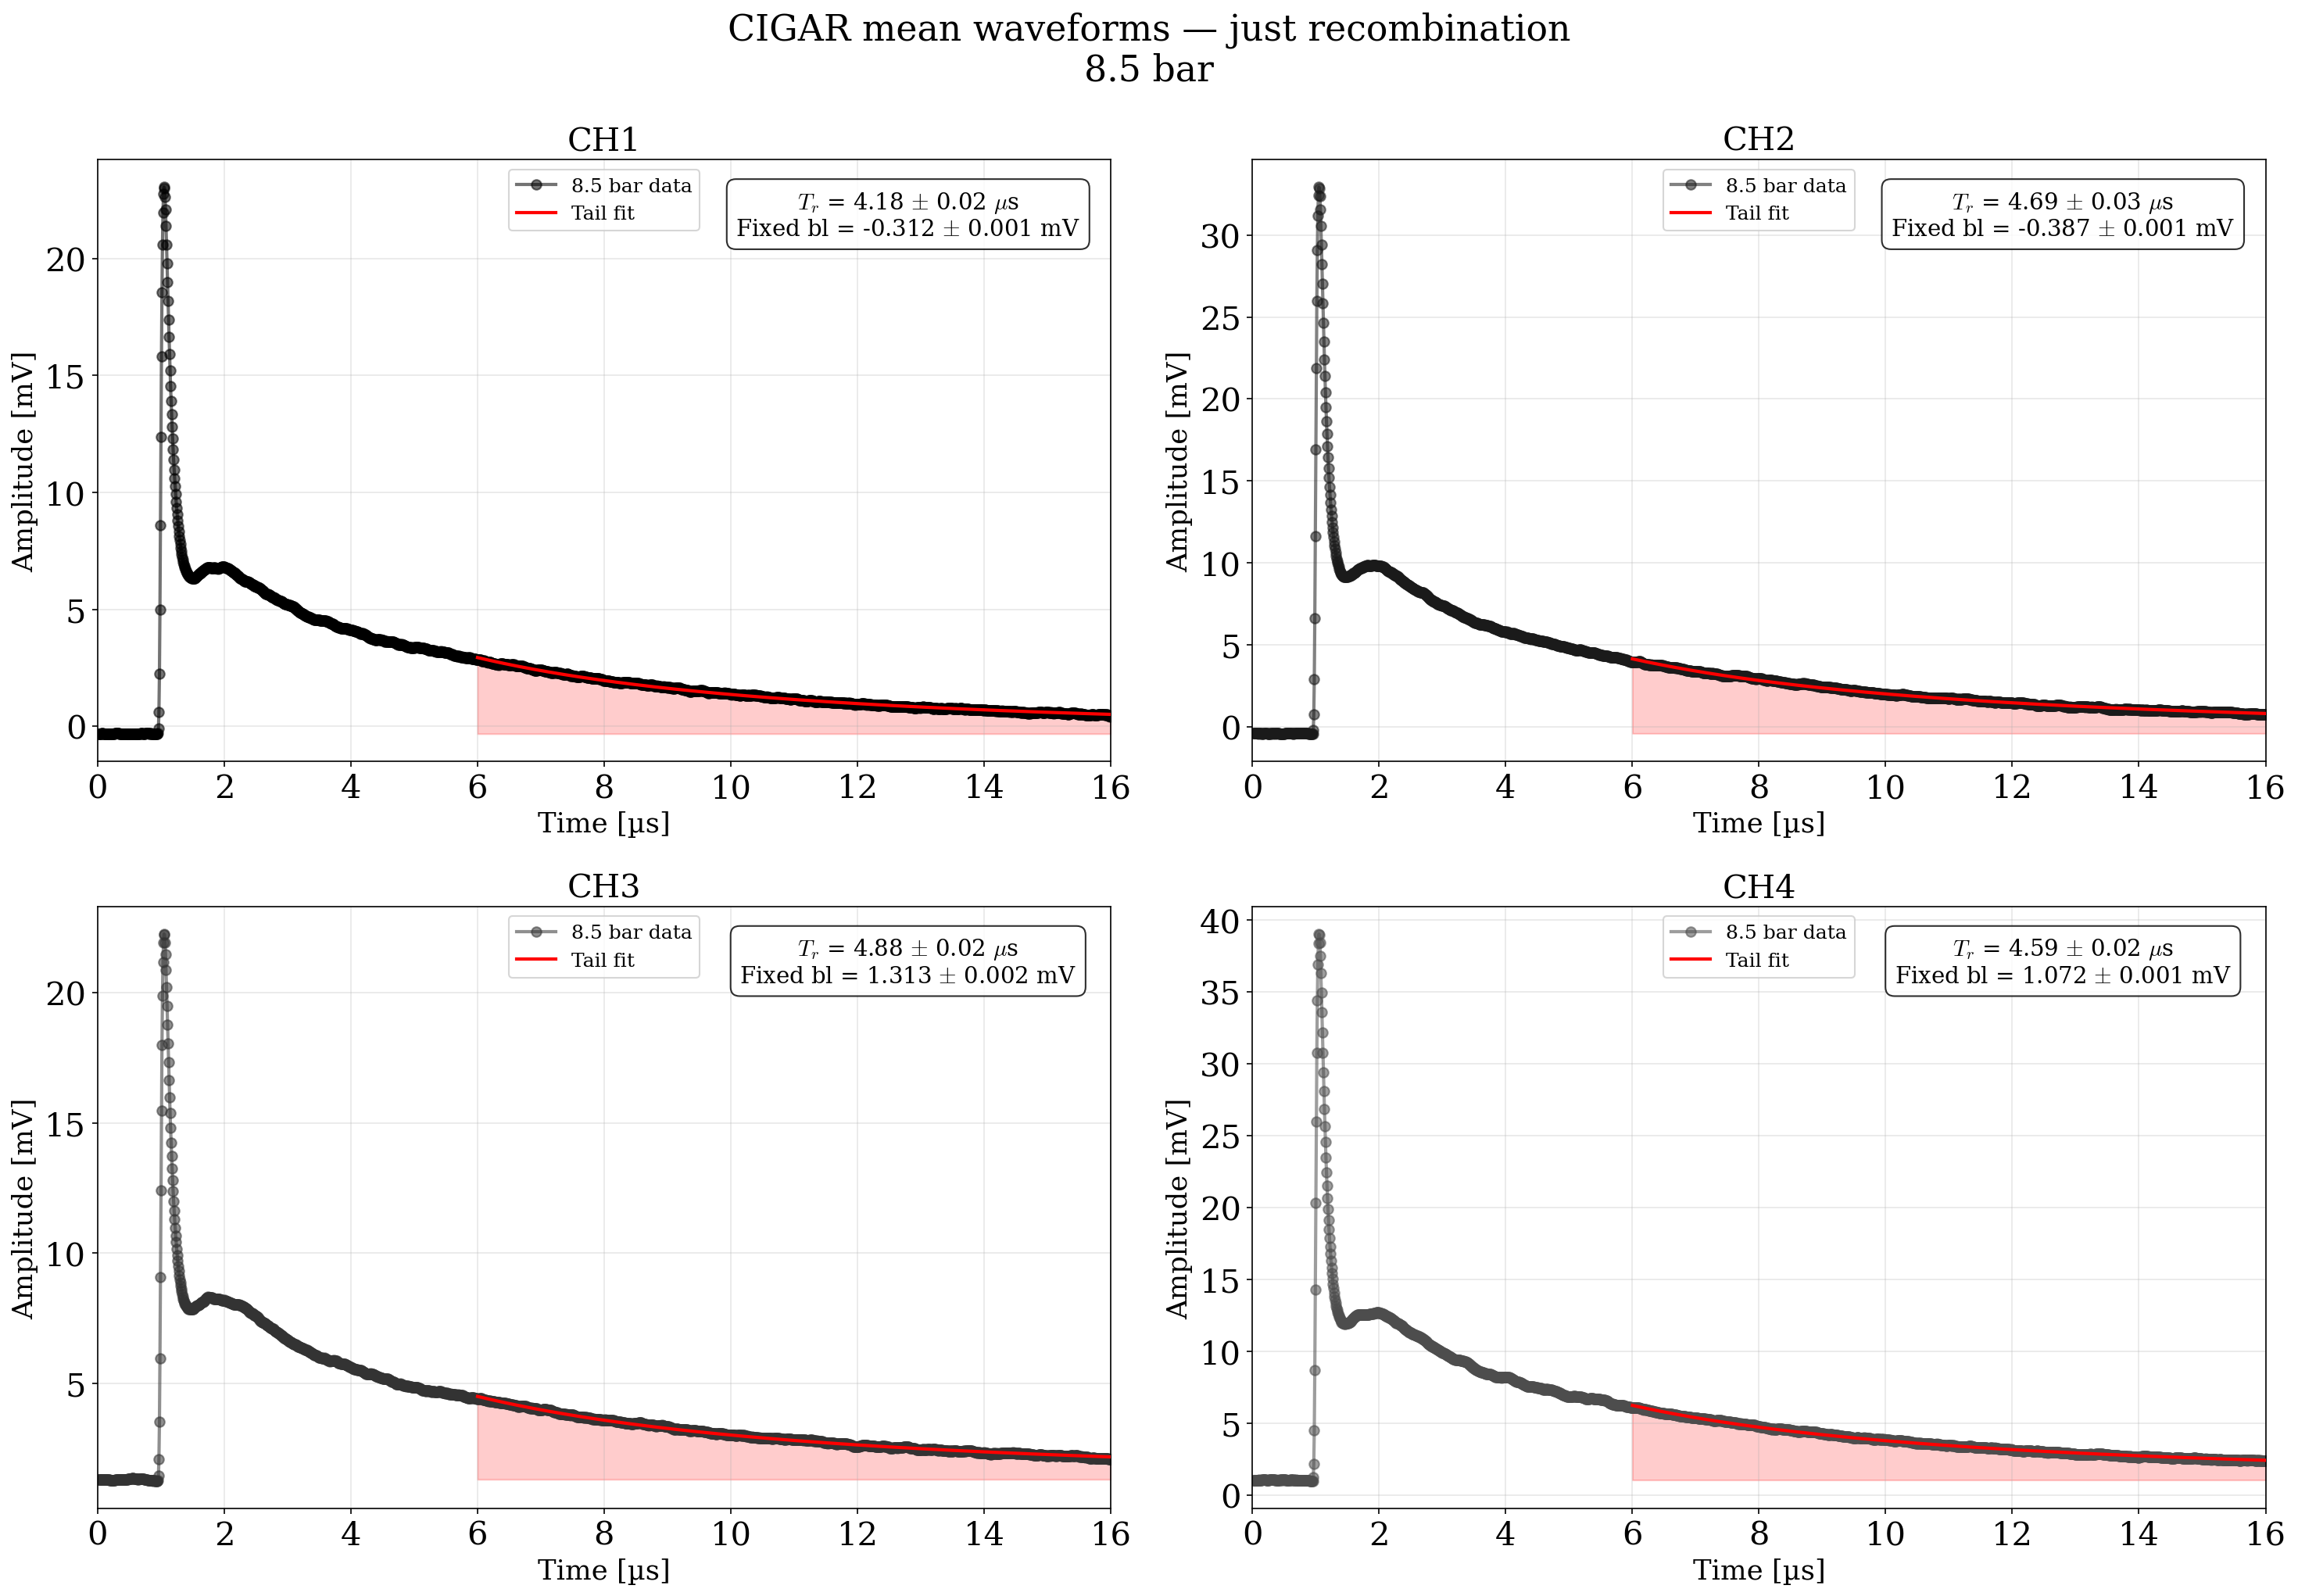

In [201]:
fig_cig, axs, cigar_params = fit_cigar_waveforms(run, base, pretrigger_sample=pretrigger,
                                                 t0_fit = t0_fit,
                                                 channels_to_show=None, invert=True,
                                                 colors=colors, font_size=20, logscale=False)

# for ax in axs.flatten():
#     # ax.set_ylim(1, 30)
#     ax.set_ylim(-1, 1.5)
#     ax.set_xlim(0, 1)
    
plt.show()


In [202]:
runs = {
    8.5: f"Run{171}",
    7.5: f"Run{173}",
    6.5: f"Run{175}",
    5.5: f"Run{177}",
    4.5: f"Run{179}",
    3.5: f"Run{181}",
    # 2.5: f"Run{183}",
    # 1.5: f"Run{185}",
}


In [203]:
check_aprox_validity = False

  CH1 @ 8.5 bar:  Tr_guess = 3.21 µs
  CH2 @ 8.5 bar:  Tr_guess = 3.21 µs
  CH3 @ 8.5 bar:  Tr_guess = 3.21 µs
  CH4 @ 8.5 bar:  Tr_guess = 3.21 µs


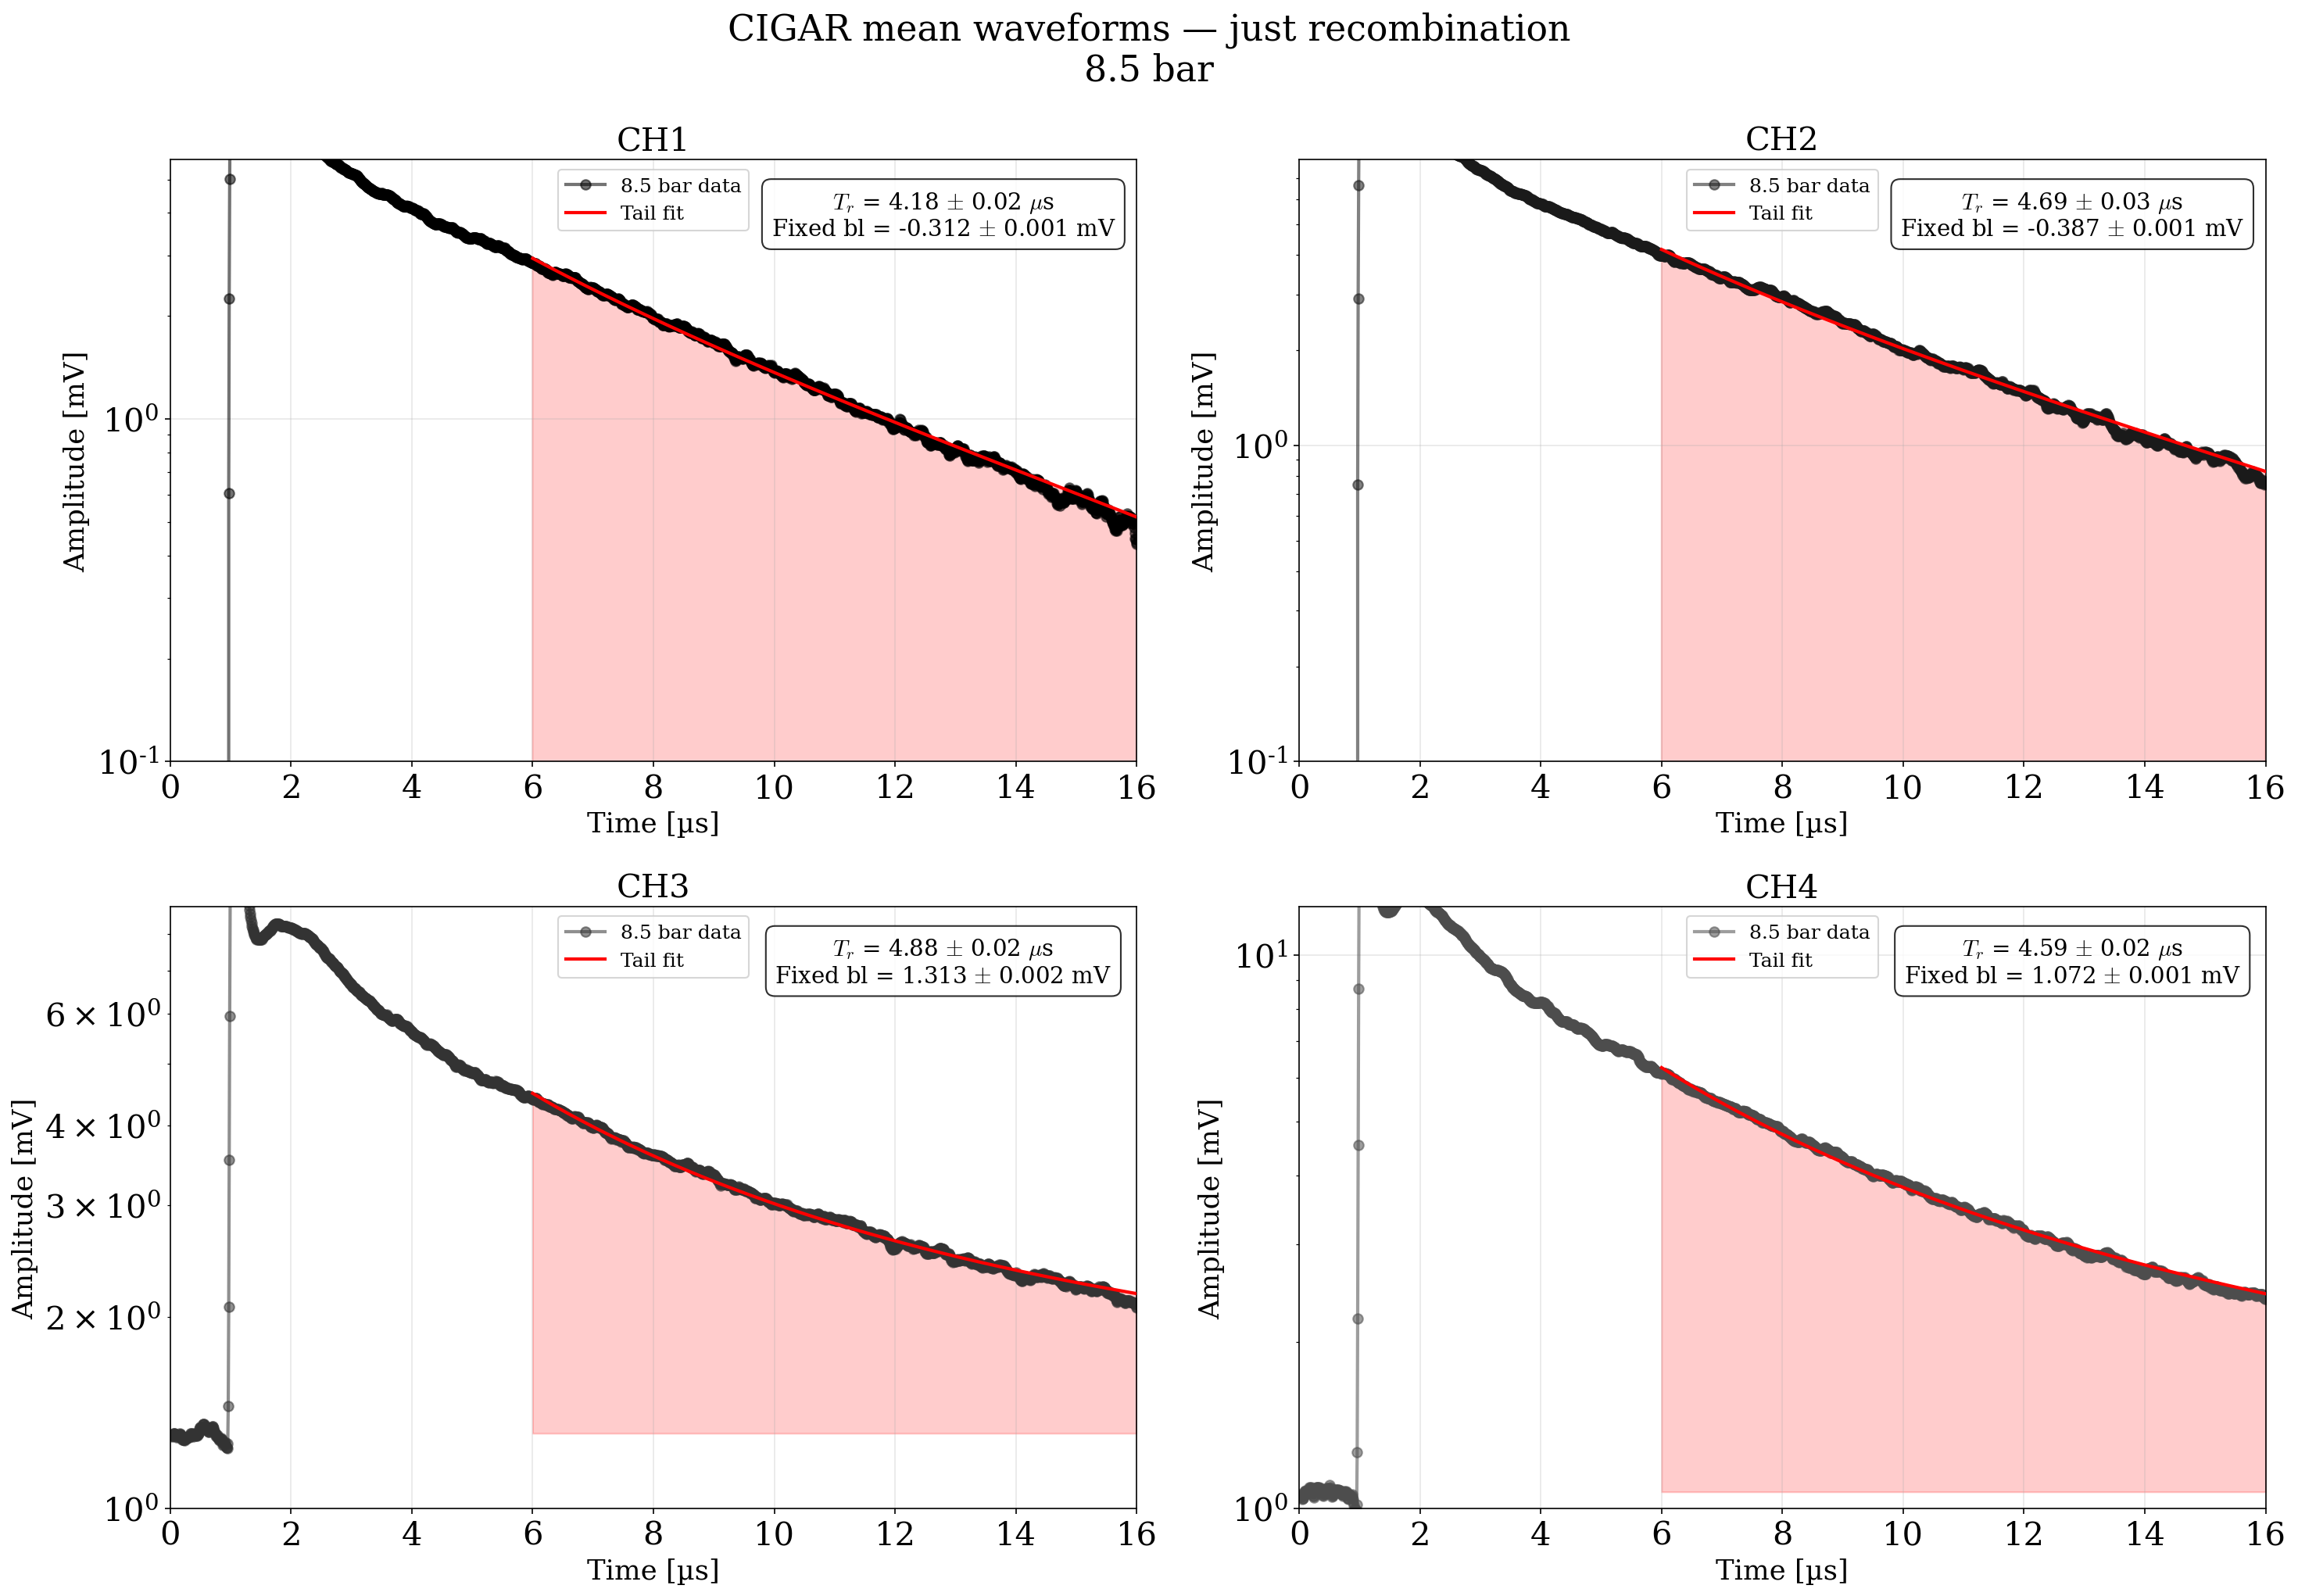

  ⚠ [CH1] 8.5 bar — pcov ill-conditioned (cond=5.6e+15), errors unreliable
  ⚠ [CH2] 8.5 bar — pcov ill-conditioned (cond=5.2e+15), errors unreliable
  ⚠ [CH3] 8.5 bar — pcov ill-conditioned (cond=2.0e+15), errors unreliable
  ⚠ [CH4] 8.5 bar — pcov ill-conditioned (cond=7.9e+15), errors unreliable
  CH1 @ 7.5 bar:  Tr_guess = 4.49 µs
  CH2 @ 7.5 bar:  Tr_guess = 4.49 µs
  CH3 @ 7.5 bar:  Tr_guess = 4.49 µs
  CH4 @ 7.5 bar:  Tr_guess = 4.49 µs


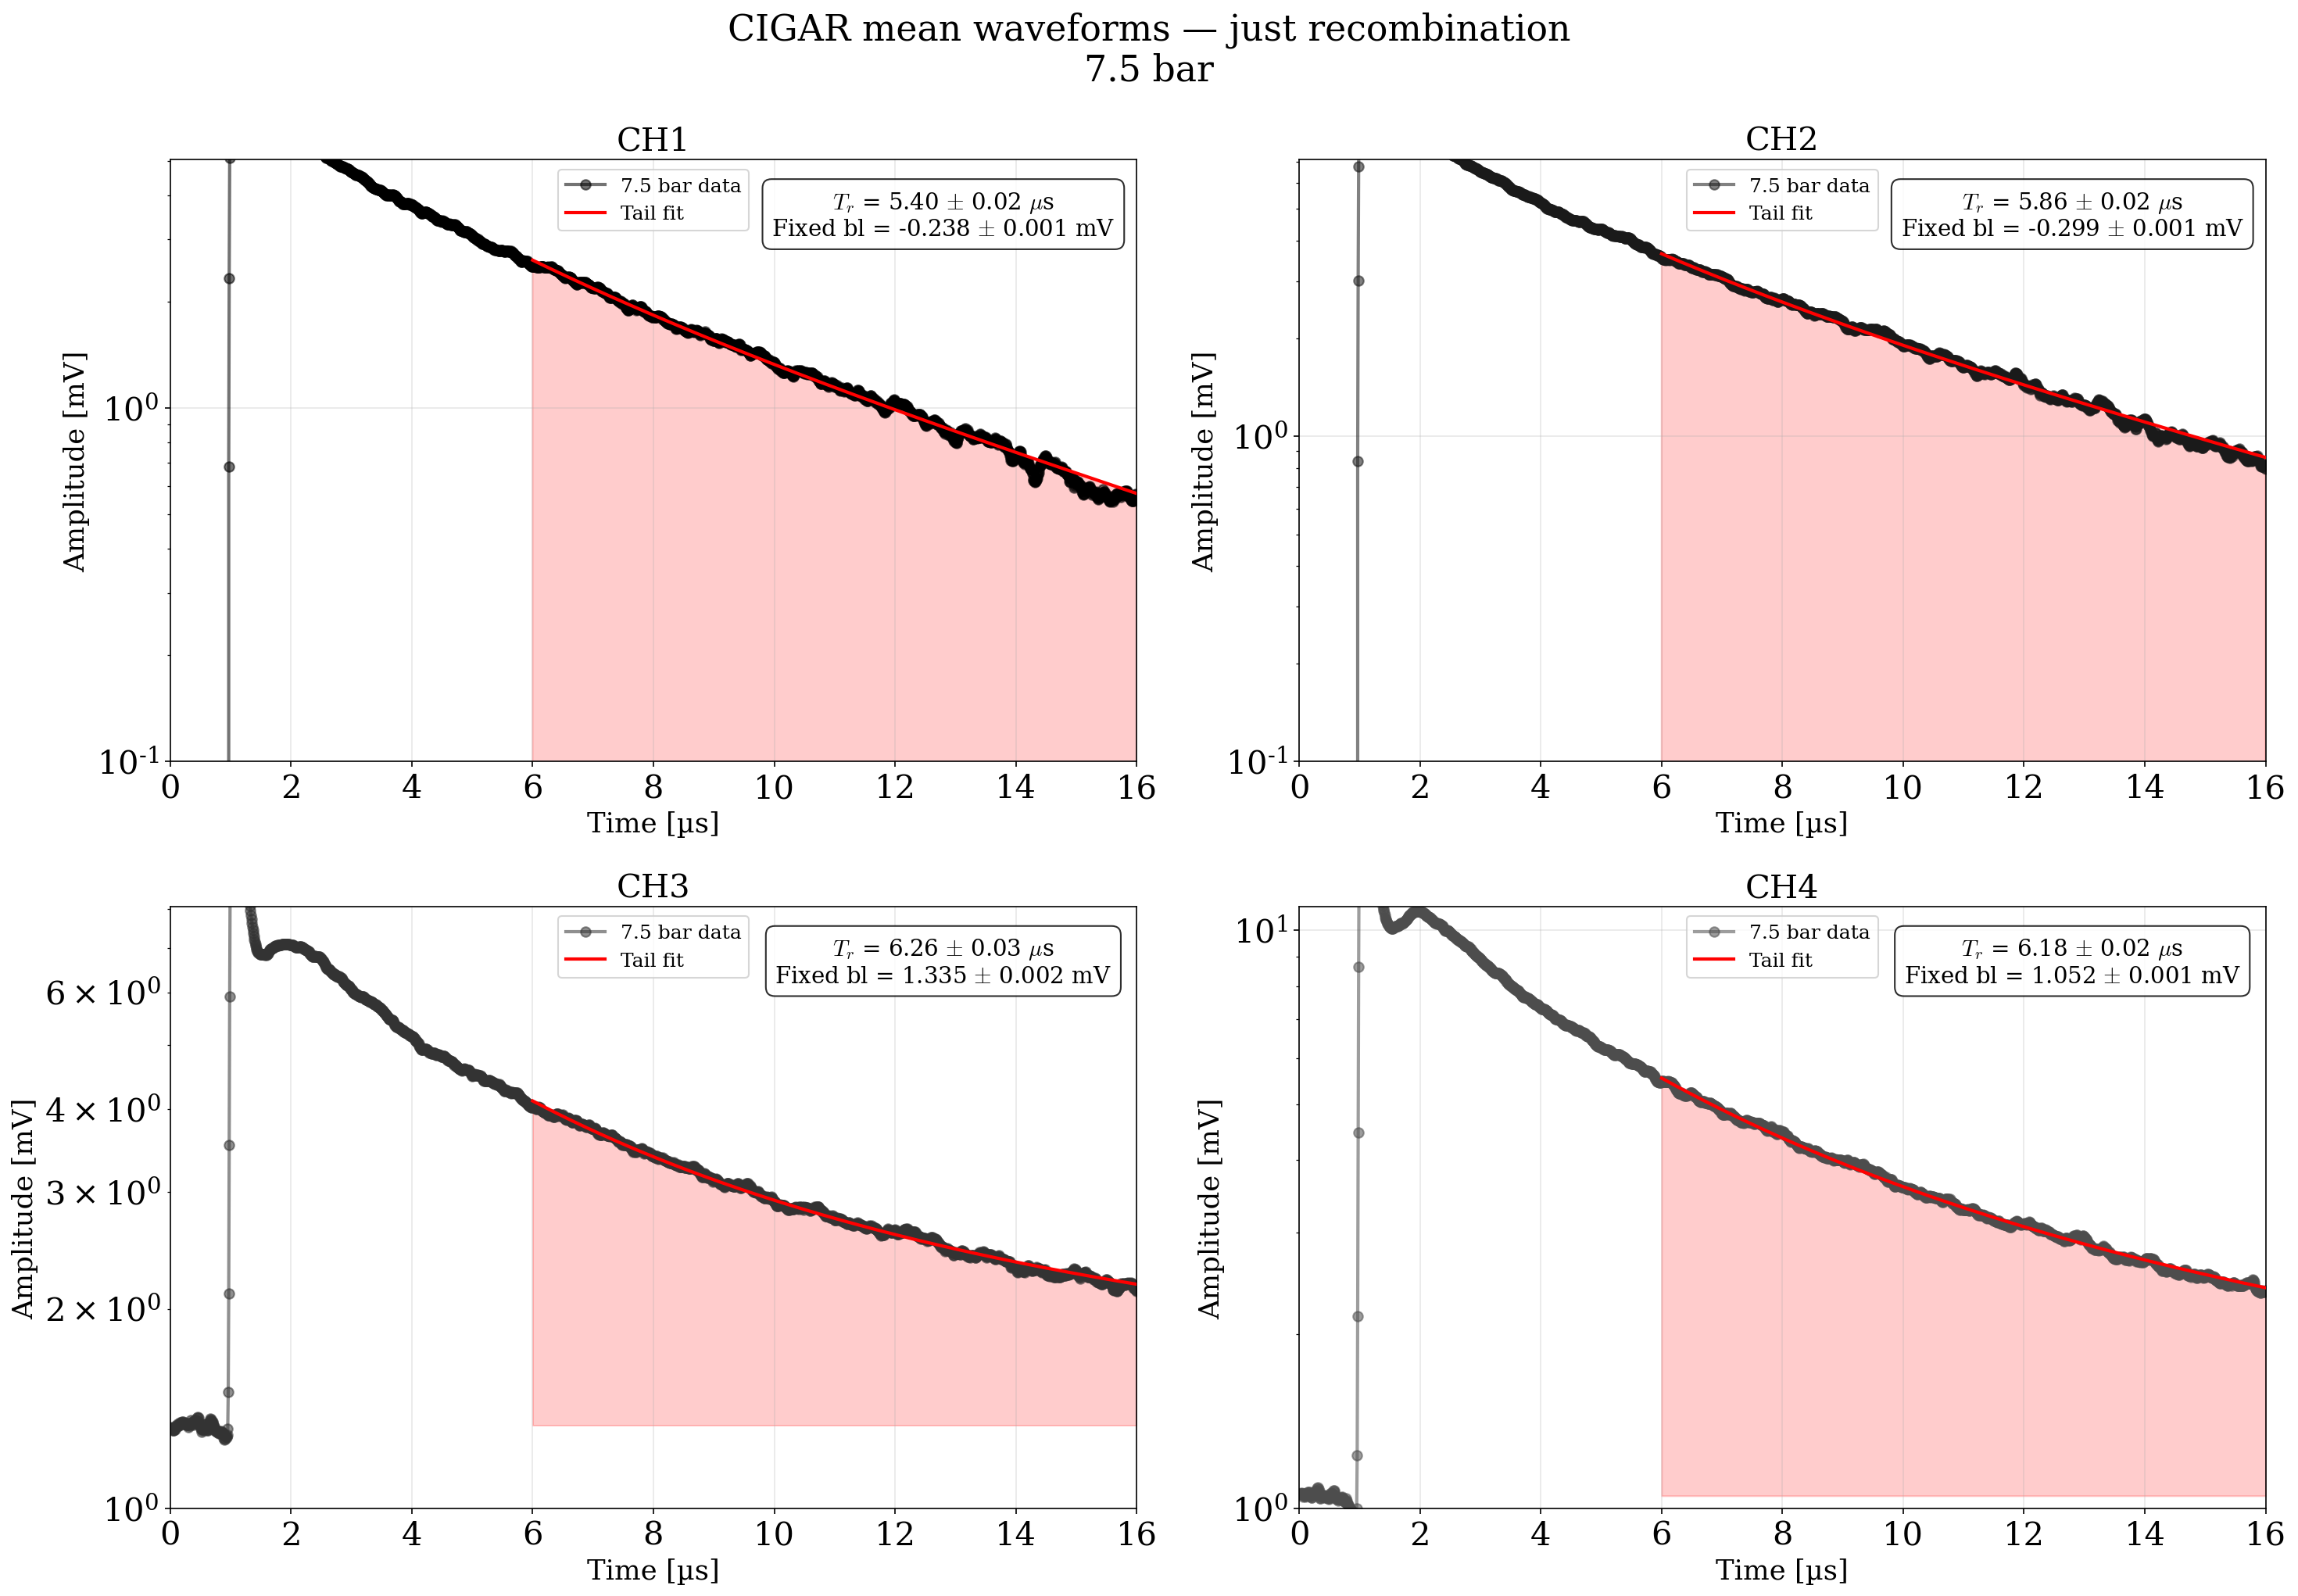

  ⚠ [CH1] 7.5 bar — pcov ill-conditioned (cond=8.7e+14), errors unreliable
  ⚠ [CH2] 7.5 bar — pcov ill-conditioned (cond=1.0e+15), errors unreliable
  ⚠ [CH3] 7.5 bar — pcov ill-conditioned (cond=3.4e+14), errors unreliable
  ⚠ [CH4] 7.5 bar — pcov ill-conditioned (cond=9.5e+14), errors unreliable
  CH1 @ 6.5 bar:  Tr_guess = 6.61 µs
  CH2 @ 6.5 bar:  Tr_guess = 6.61 µs
  CH3 @ 6.5 bar:  Tr_guess = 6.61 µs
  CH4 @ 6.5 bar:  Tr_guess = 6.61 µs


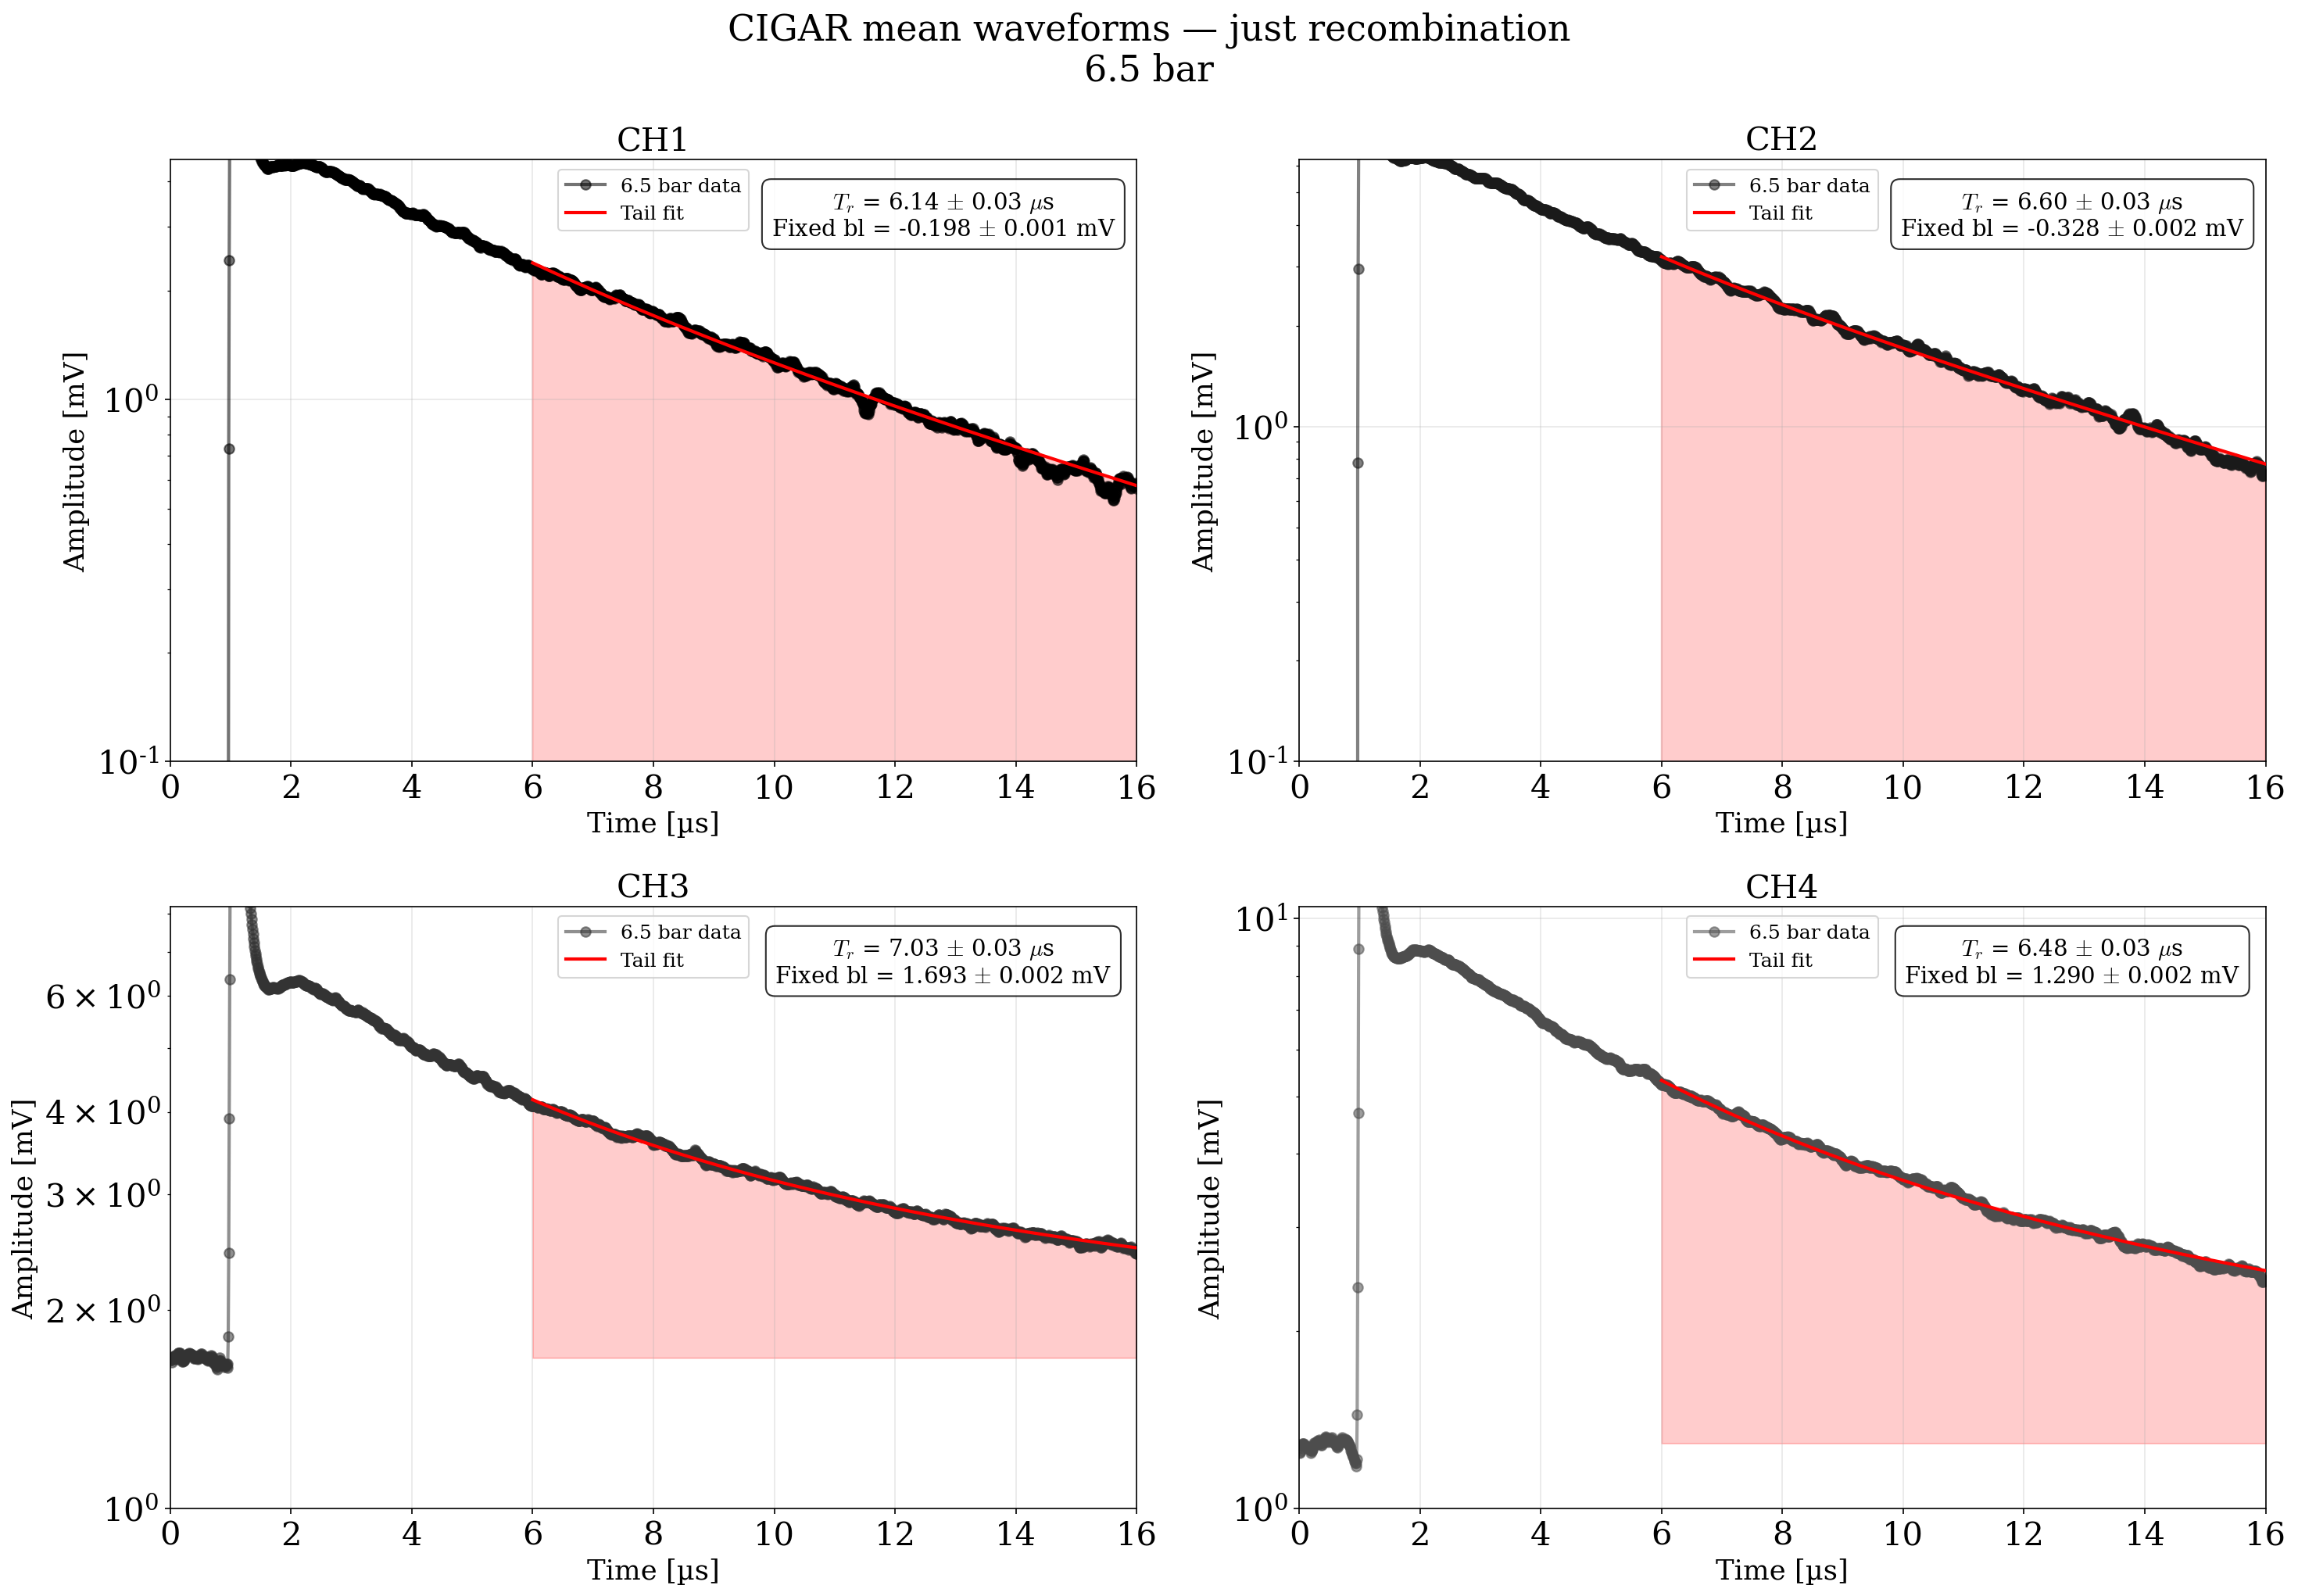

  ⚠ [CH1] 6.5 bar — pcov ill-conditioned (cond=3.3e+14), errors unreliable
  ⚠ [CH2] 6.5 bar — pcov ill-conditioned (cond=4.0e+14), errors unreliable
  ⚠ [CH3] 6.5 bar — pcov ill-conditioned (cond=1.4e+14), errors unreliable
  ⚠ [CH4] 6.5 bar — pcov ill-conditioned (cond=5.8e+14), errors unreliable
  CH1 @ 5.5 bar:  Tr_guess = 10.39 µs
  CH2 @ 5.5 bar:  Tr_guess = 10.39 µs
  CH3 @ 5.5 bar:  Tr_guess = 10.39 µs
  CH4 @ 5.5 bar:  Tr_guess = 10.39 µs


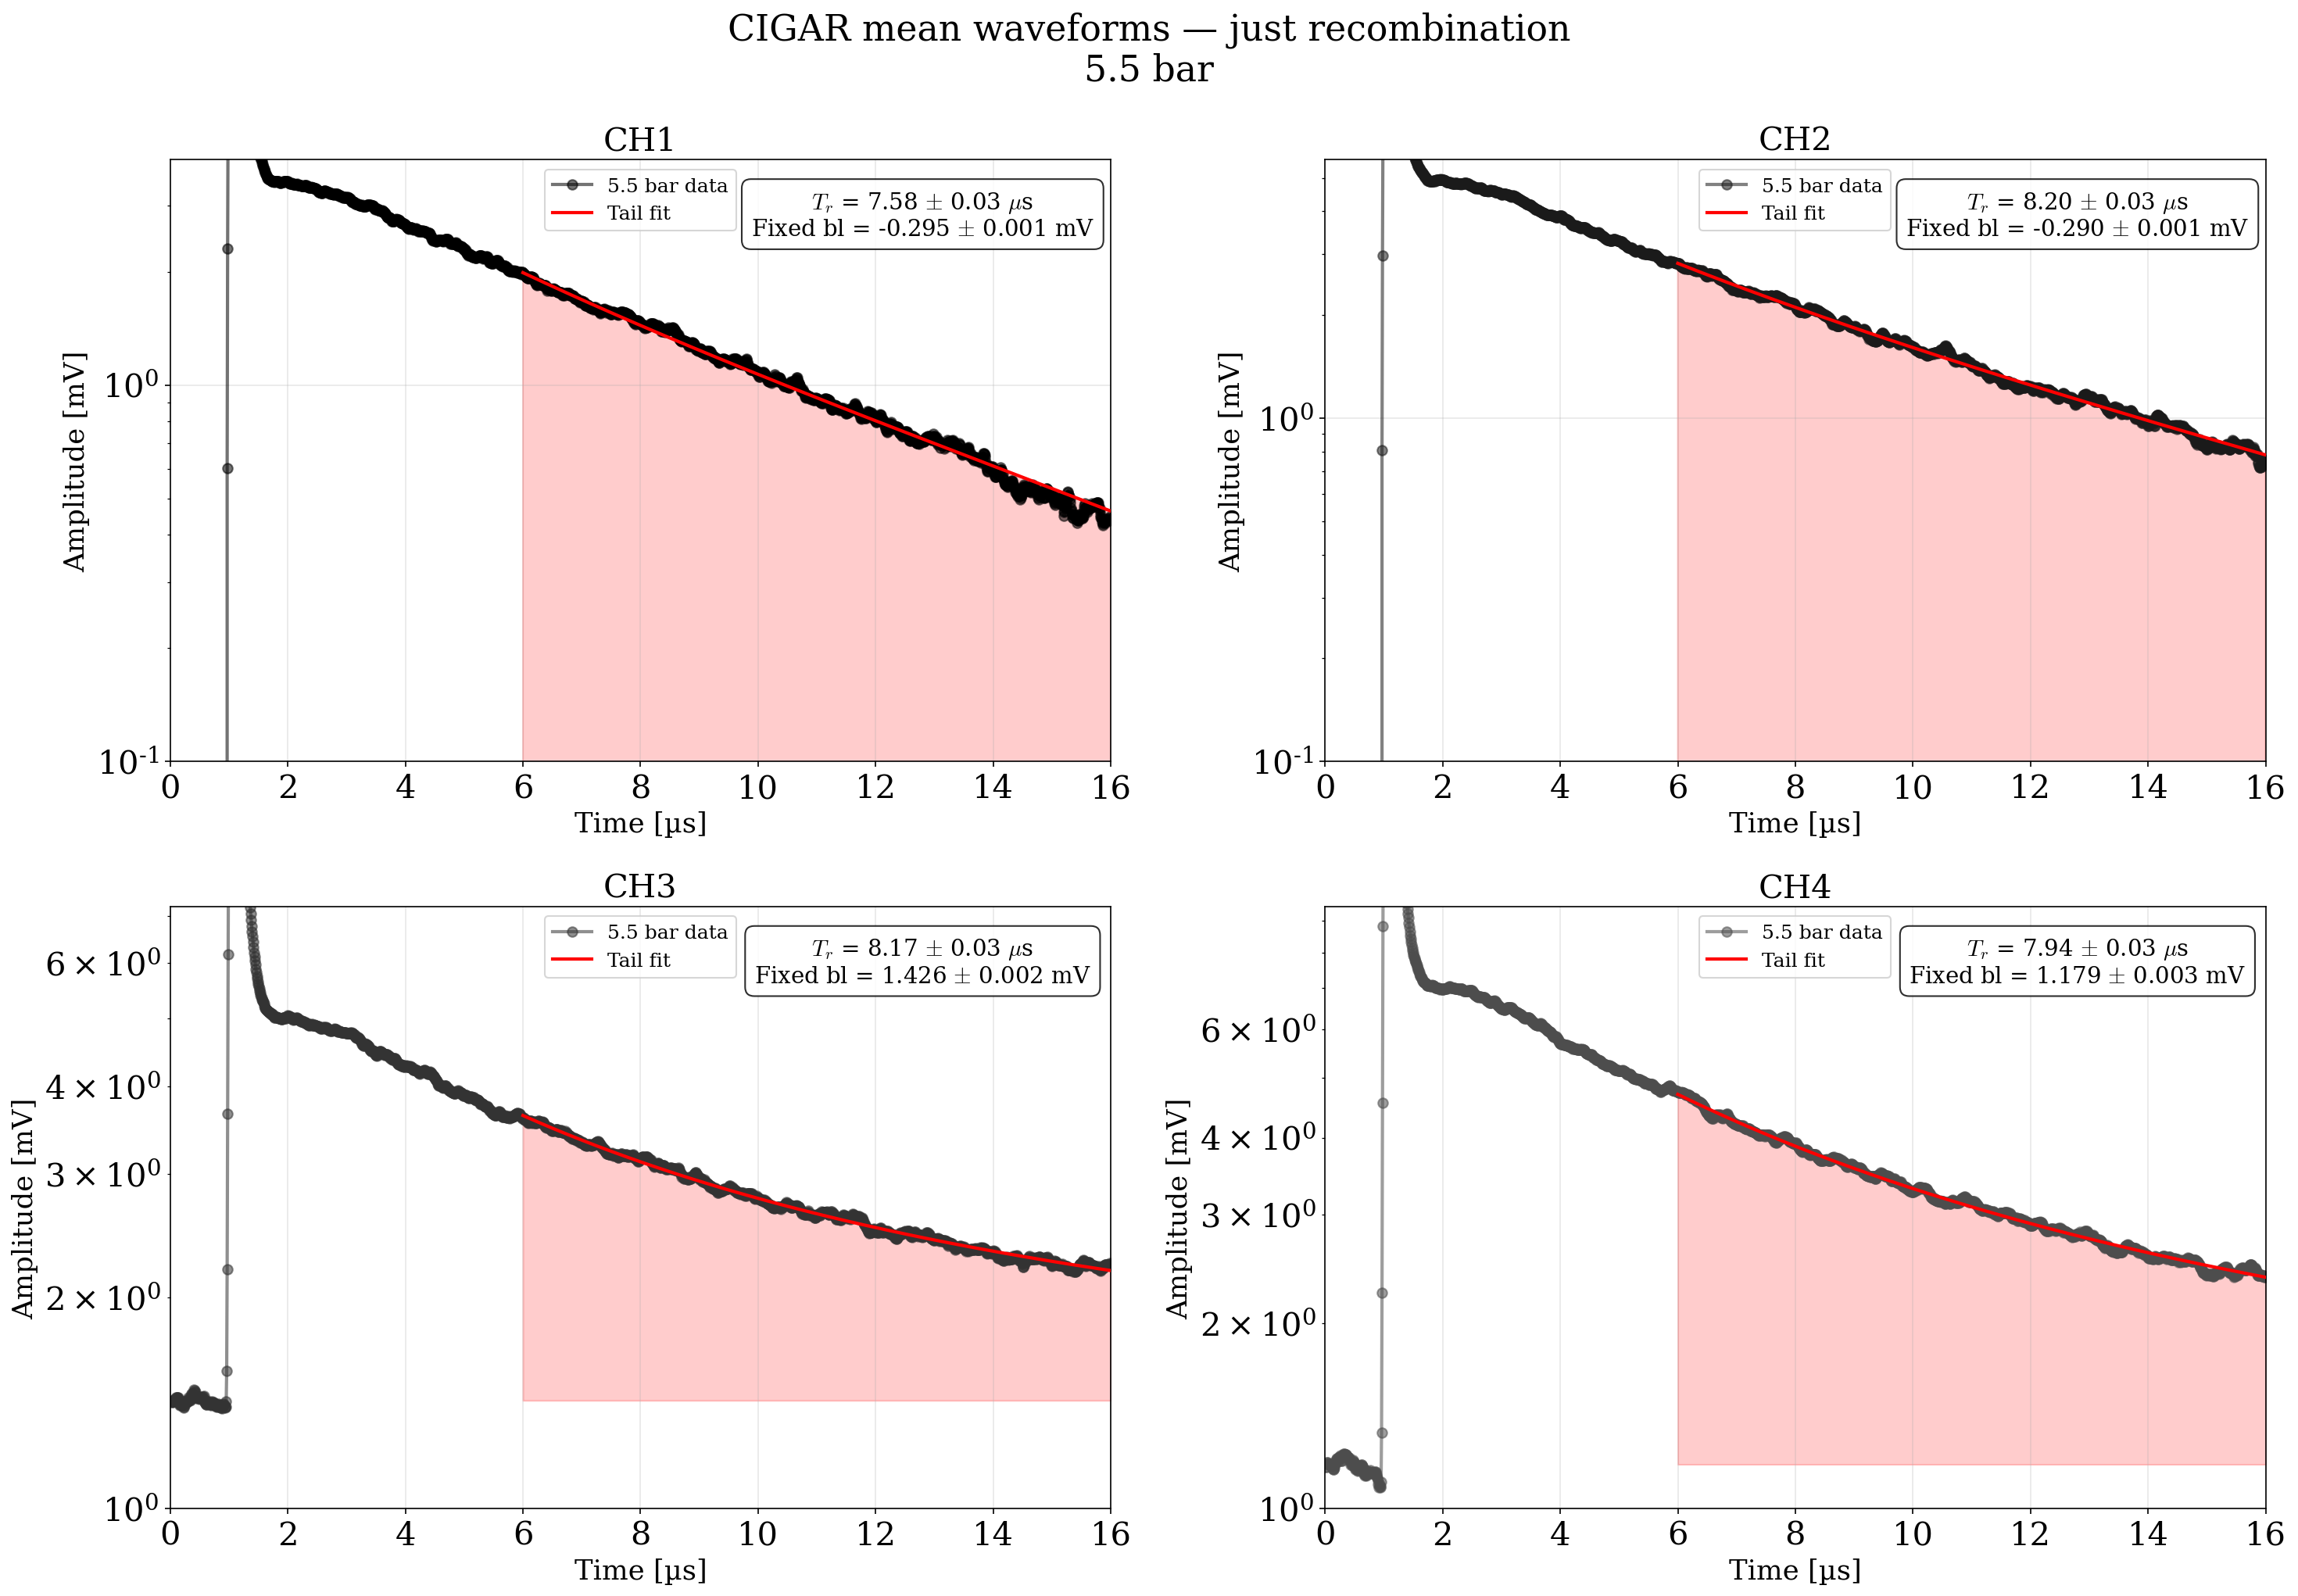

  ⚠ [CH1] 5.5 bar — pcov ill-conditioned (cond=7.5e+13), errors unreliable
  ⚠ [CH2] 5.5 bar — pcov ill-conditioned (cond=8.9e+13), errors unreliable
  ⚠ [CH3] 5.5 bar — pcov ill-conditioned (cond=4.6e+13), errors unreliable
  ⚠ [CH4] 5.5 bar — pcov ill-conditioned (cond=1.4e+14), errors unreliable
  CH1 @ 4.5 bar:  Tr_guess = 17.85 µs
  CH2 @ 4.5 bar:  Tr_guess = 17.85 µs
  CH3 @ 4.5 bar:  Tr_guess = 17.85 µs
  CH4 @ 4.5 bar:  Tr_guess = 17.85 µs


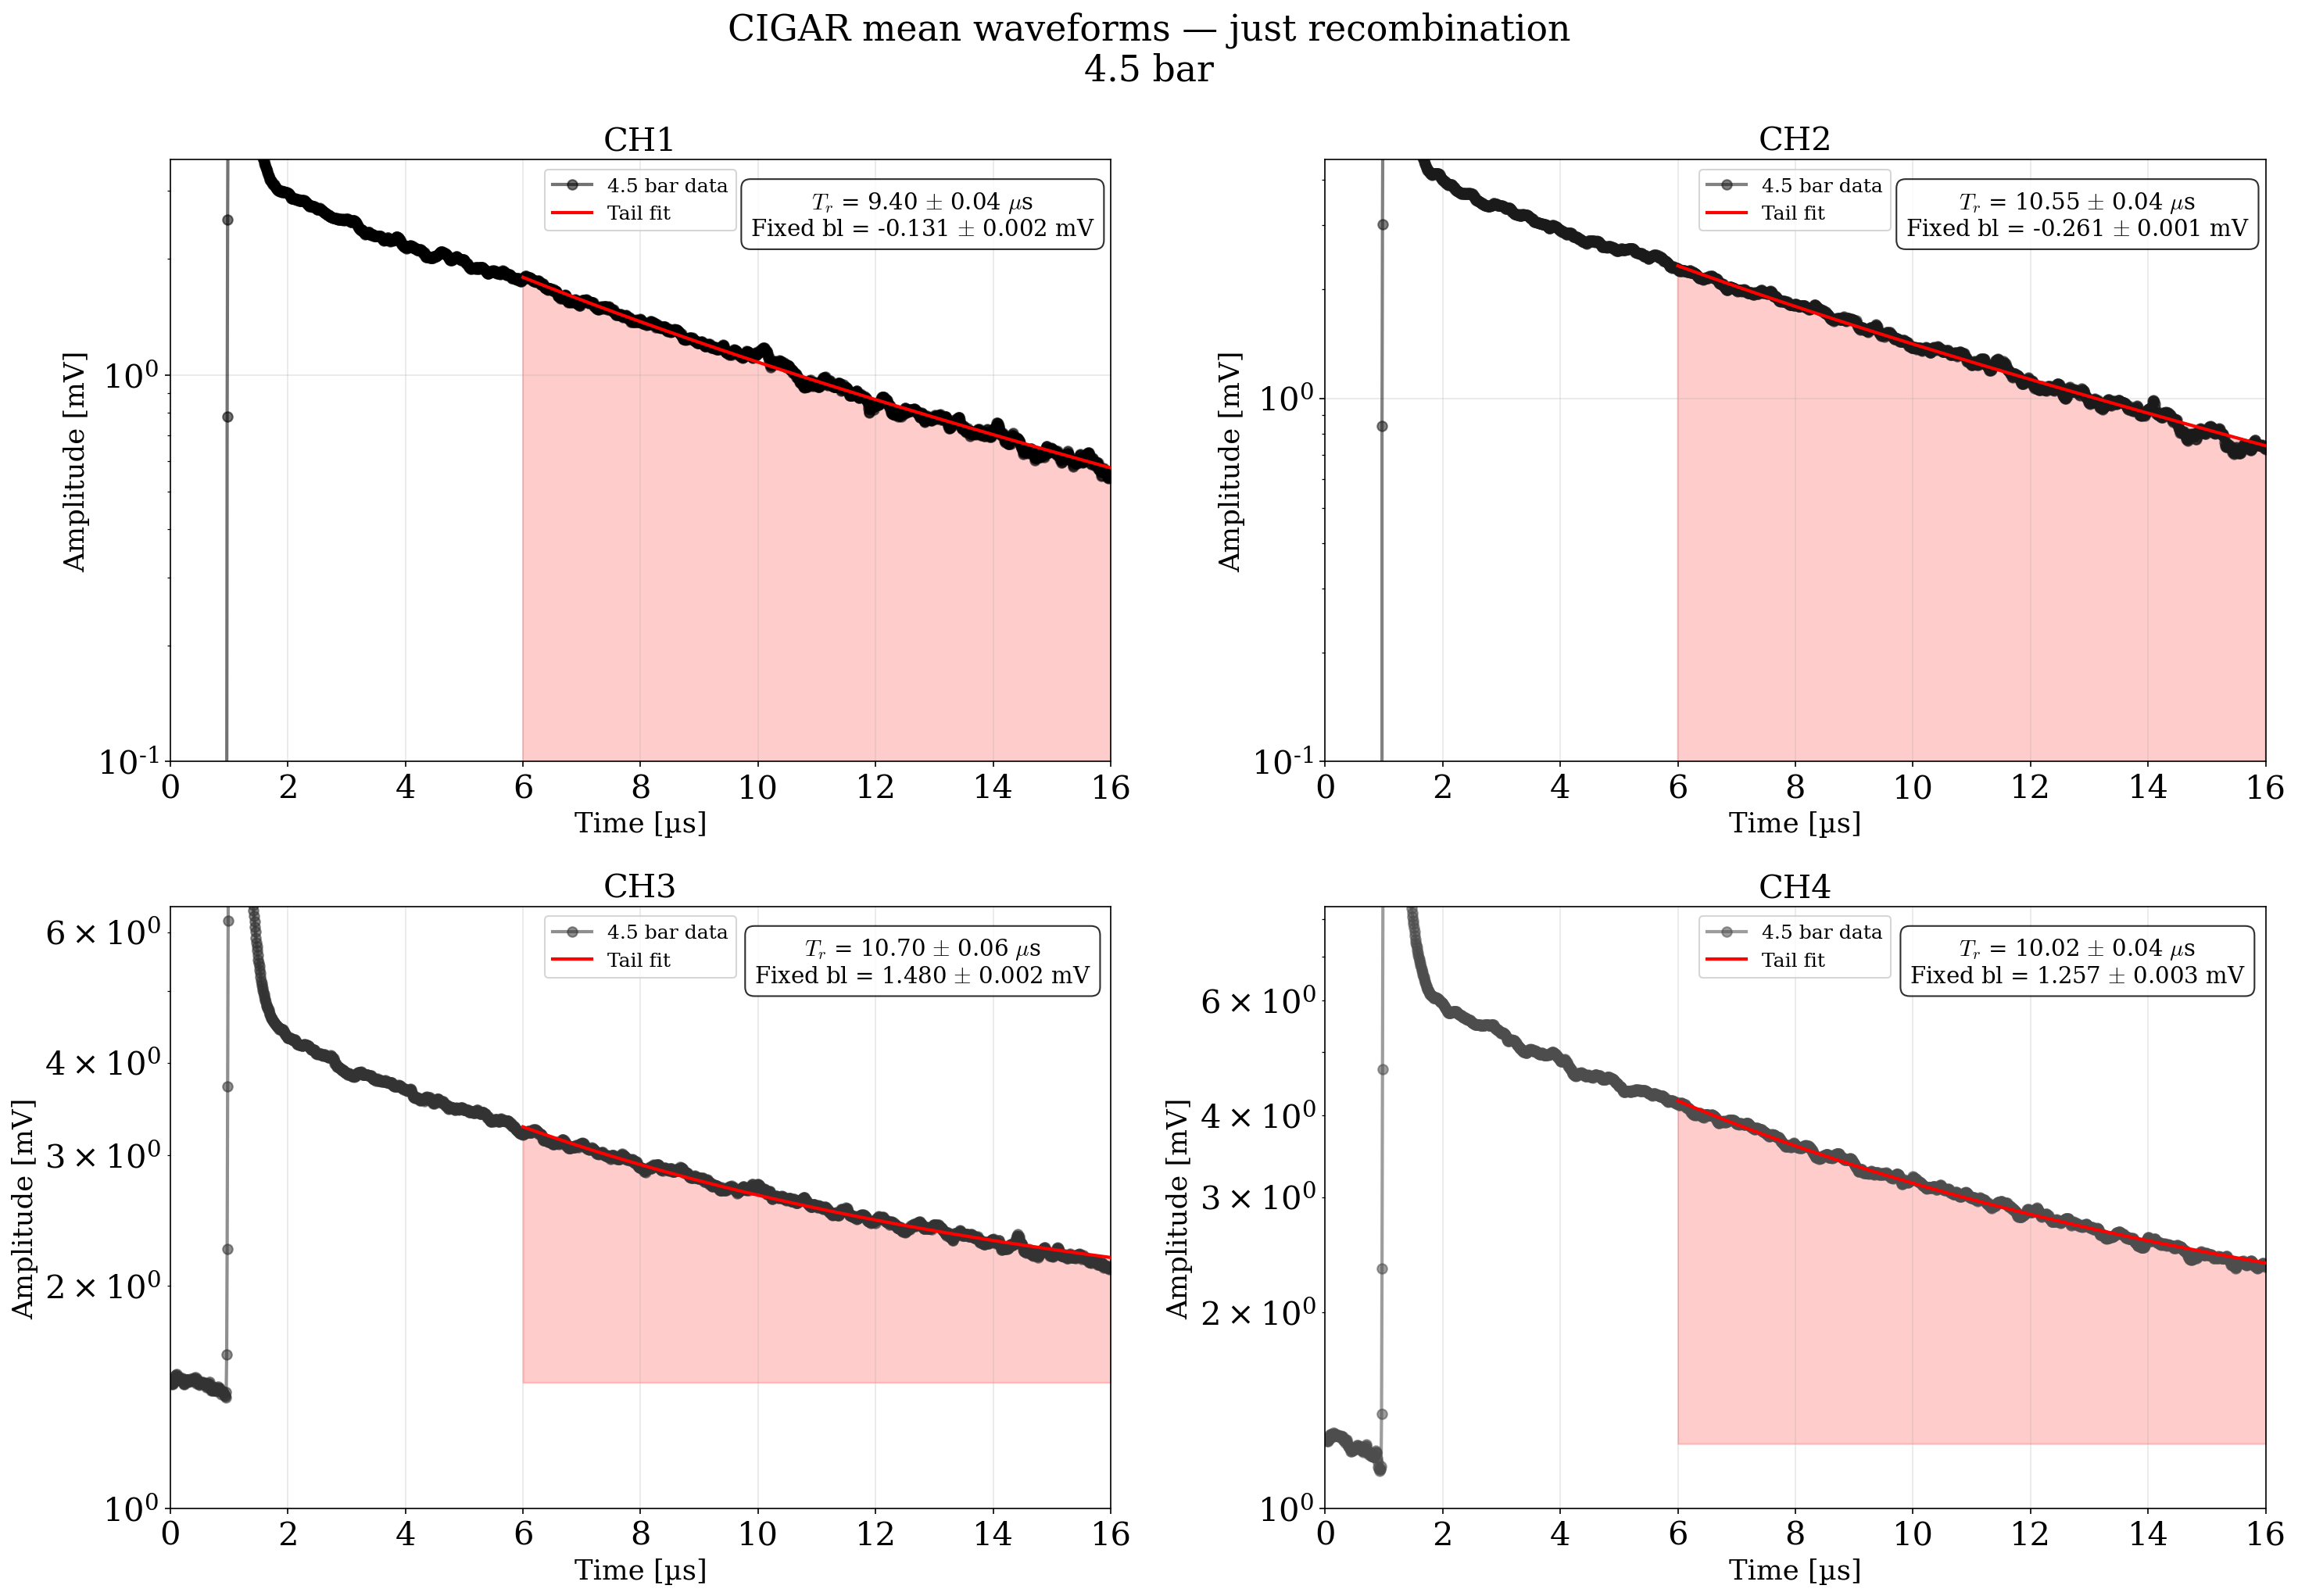

  ⚠ [CH1] 4.5 bar — pcov ill-conditioned (cond=1.6e+13), errors unreliable
  ⚠ [CH2] 4.5 bar — pcov ill-conditioned (cond=1.5e+13), errors unreliable
  ⚠ [CH3] 4.5 bar — pcov ill-conditioned (cond=6.9e+12), errors unreliable
  ⚠ [CH4] 4.5 bar — pcov ill-conditioned (cond=2.7e+13), errors unreliable
  CH1 @ 3.5 bar:  Tr_guess = 35.19 µs
  CH2 @ 3.5 bar:  Tr_guess = 35.19 µs
  CH3 @ 3.5 bar:  Tr_guess = 35.19 µs
  CH4 @ 3.5 bar:  Tr_guess = 35.19 µs


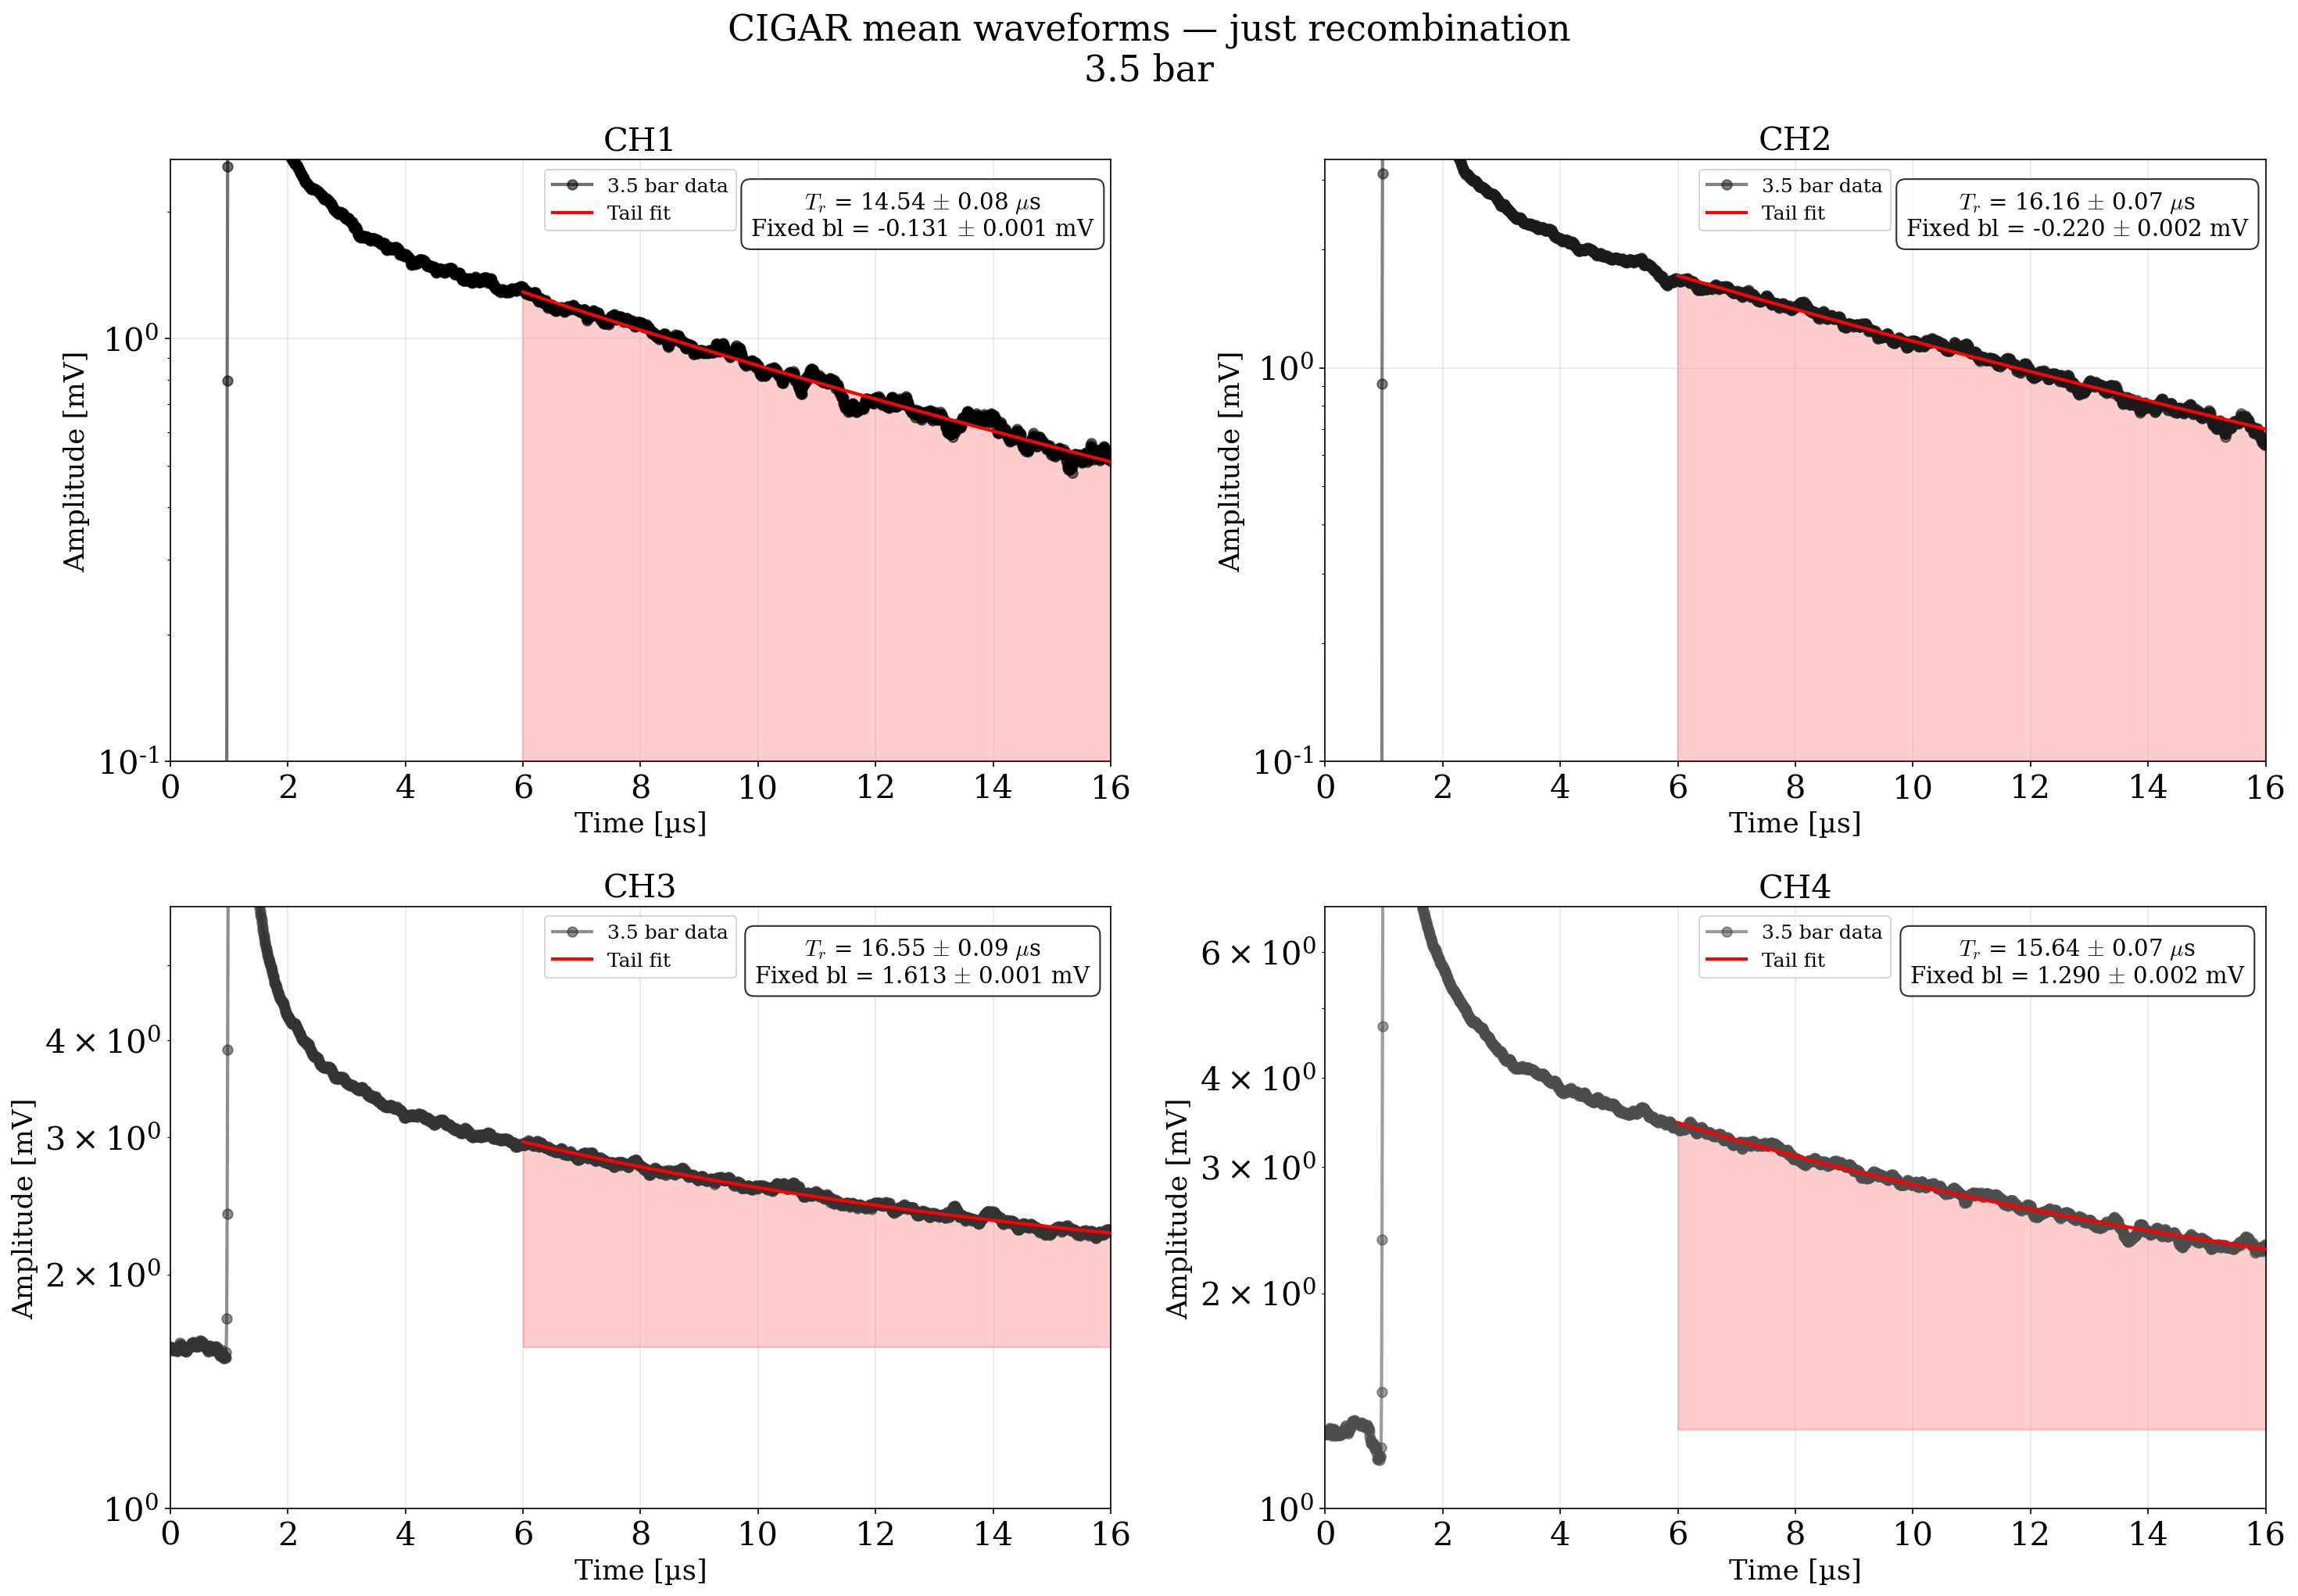

  ⚠ [CH1] 3.5 bar — pcov ill-conditioned (cond=8.9e+11), errors unreliable
  ⚠ [CH2] 3.5 bar — pcov ill-conditioned (cond=9.7e+11), errors unreliable
  ⚠ [CH3] 3.5 bar — pcov ill-conditioned (cond=4.2e+11), errors unreliable
  ⚠ [CH4] 3.5 bar — pcov ill-conditioned (cond=1.4e+12), errors unreliable

DONE!


In [204]:
# singlet, triplet, recombination per channel per pressure
rec_A, rec_Tr, rec_bl = {}, {}, {}

# Store waveform/fit arrays for the final summary figure
all_fits = {}  # {bars: {sphe_key: {t_fit, wf_fit, wf_model, h_singlet, h_triplet, h_rec, bl, fit_ok}}}

prev_cp = None  # warm-start from previous (higher) pressure


for bars, run_name in sorted(runs.items(), reverse=True):   # 8.5 -> 1.5 bar
    run = {bars: run_name}


    fig, axs_cig, cp = fit_cigar_waveforms(run, base, pretrigger_sample=pretrigger,
                                           t0_fit=t0_fit,
                                           channels_to_show=None, invert=True,
                                           colors=colors, font_size=20, logscale=True
                                           )
    plt.show()

    # reload raw waveforms and reconstruct branches for summary figure
    run_name_fmt = run_name if not isinstance(run_name, int) else f"Run{run_name}"
    npz          = np.load(f"{base}/mean_waveforms/mean_waveforms_{run_name_fmt}.npz", allow_pickle=True)
    channels_arr = npz["channels"]
    time_arr     = npz["time"]
    all_fits[bars] = {}

    for ch_idx, ch in enumerate(channels_arr):
        sk = f"CH{ch_idx+1}"
        if sk not in cp: continue
        p    = cp[sk]
        wf   = -npz[f"ch_{ch}"].copy()
        fit_mask = time_arr >= t0_fit
        t_fit    = time_arr[fit_mask]
        wf_fit   = wf[fit_mask]

        A, Tr_ = p["A"], p["Tr"]
        bl = p["baseline"]


        # 9. FIT FUNCTION
        def fit_fn(t, A, Tr):
            return decay_tail(t, A, Tr, bl)

        wf_model = decay_tail(t_fit, A, Tr_, bl)

        all_fits[bars][sk] = dict(t = time_arr, wf = wf,
                                  t_fit=t_fit, wf_fit=wf_fit,
                                  bl=bl, fit_ok=not np.any(np.isnan(p["pcov"])),
                                  )

    # accumulate decay-time tables
    # NOTE: _e is defined as a local function with explicit argument capture
    # to avoid the Python closure-over-loop-variable bug (all closures
    # defined inside a loop share the same 'cov' reference otherwise).
    for ch in cp:
        cov  = cp[ch]["pcov"]
        cond = np.linalg.cond(cov) if not np.any(np.isnan(cov)) else np.inf
        if np.any(np.isnan(cov)):
            print(f"  ✗ [{ch}] {bars} bar — fit failed, errors are NaN")
        elif cond > 1e8:
            print(f"  ⚠ [{ch}] {bars} bar — pcov ill-conditioned (cond={cond:.1e}), errors unreliable")

        if ch not in rec_Tr:
            rec_A[ch]   = {}; rec_Tr[ch]    = {}
            rec_bl[ch]  = {}

        def _safe_err(cov_mat, idx):
            """Extract sqrt(cov[idx,idx]), returning nan if not finite."""
            val = cov_mat[idx, idx]
            return float(np.sqrt(val)) if np.isfinite(val) and val >= 0 else float('nan')

        rec_A[ch][bars]     = (cp[ch]["A"],     _safe_err(cov, 0))
        rec_Tr[ch][bars]    = (cp[ch]["Tr"],    _safe_err(cov, 1))
        rec_bl[ch][bars]    = (cp[ch]["baseline"],    _safe_err(cov, 1))



print("\nDONE!")

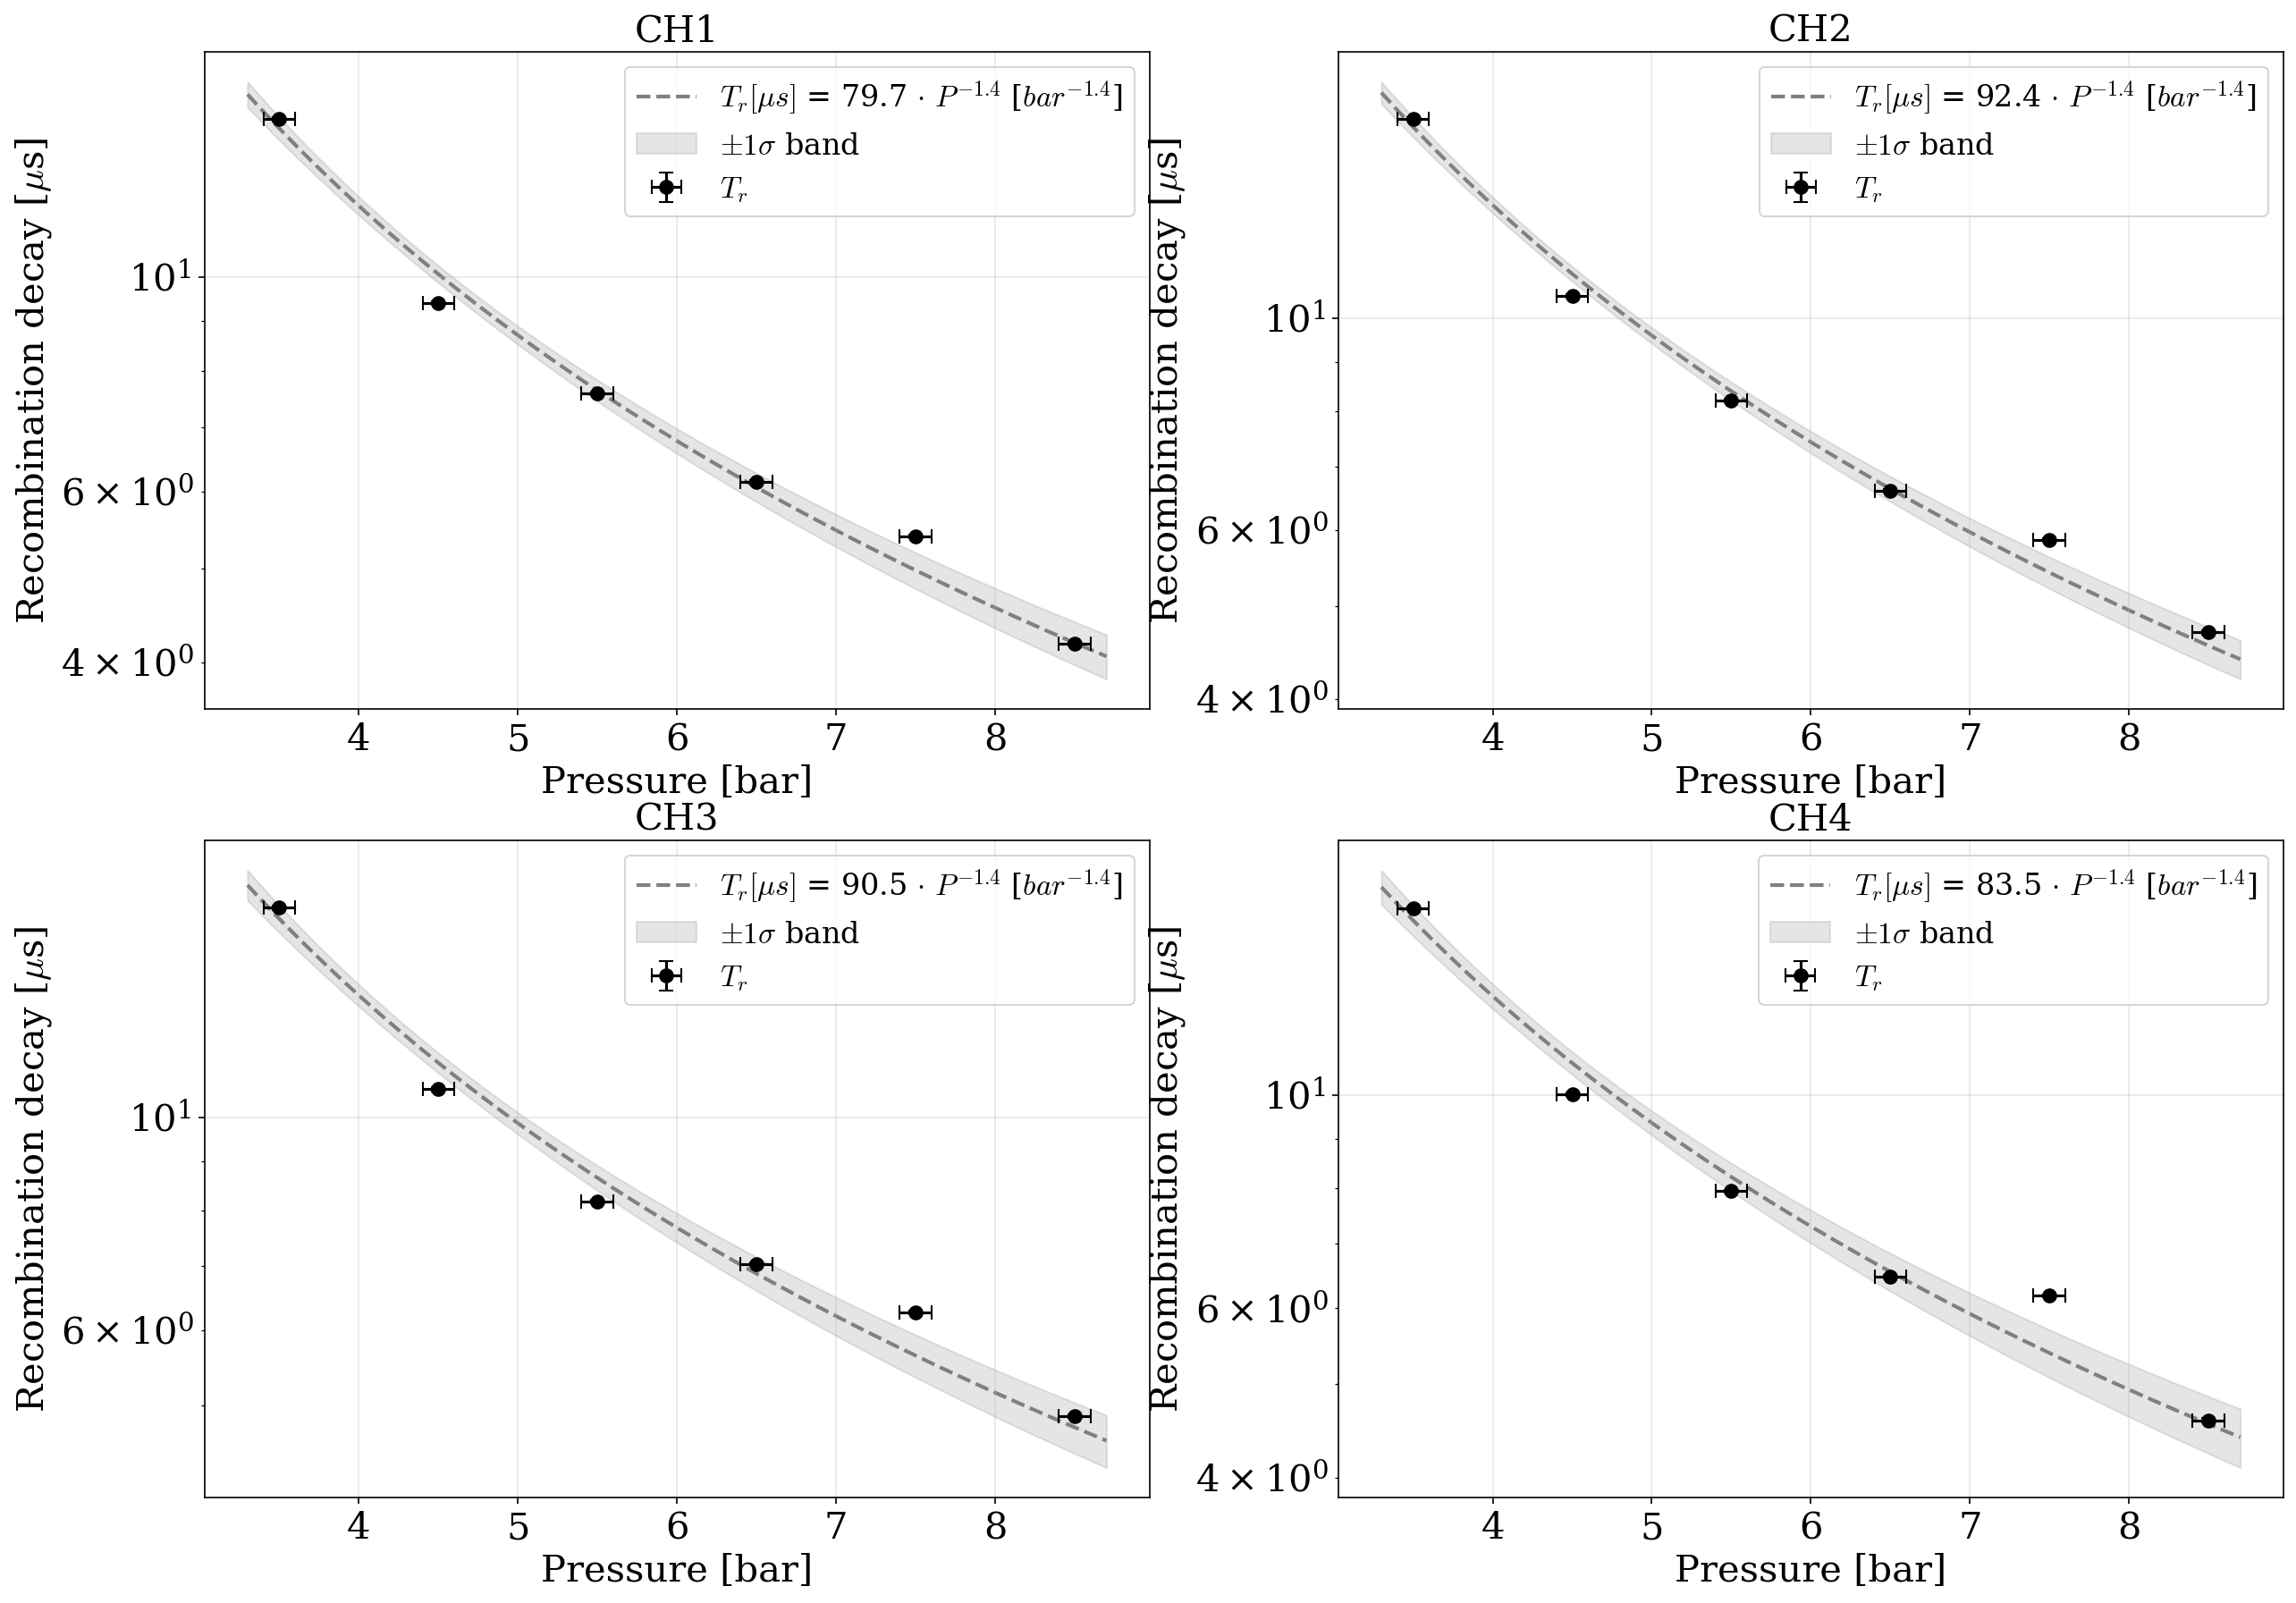

In [210]:
# Decay times vs pressure — always in B&W for publication clarity
_gs = GS_COLORS

channels_ordered = sorted(rec_Tr.keys())

channels_to_show = channels_ordered[:4]
# channels_to_show = [channels_ordered[1]]

if len(channels_to_show) > 1:
    fig_sum, axs = plt.subplots(2, 2, figsize=(20, 14), dpi=150)
else:
    fig_sum, axs = plt.subplots(1, 1, figsize=(10, 7), dpi=150)

fig.suptitle("Decay times vs pressure", fontsize=font_size + 2)

# for ii, ch in enumerate(sorted(rec_Tr.keys())):
for ii, ch in enumerate(channels_to_show):

    if np.size(axs) > 1:
        ax = axs.flat[ii]
    else:
        ax = axs

    bars_list    = sorted(rec_Tr[ch].keys())
    Tr_rec_vals  = np.array([rec_Tr[ch][b][0]       for b in bars_list]) * 1e6 # [us]
    err_rec_vals = np.array([rec_Tr[ch][b][1]       for b in bars_list]) * 1e6 # [us]
    # errors NOT capped — shown as-is so unreliable fits are visible

    ax.errorbar(np.array(bars_list), Tr_rec_vals, 
                yerr=err_rec_vals,
                xerr=0.1,
                fmt="o",  color=_gs[0], markerfacecolor=_gs[0],
                label=r"$T_{r}$", capsize=4,
                markersize=7,
                )
    

    def fit_fn(pressure_in_bar, A, power):
        pressure_in_torr = pressure_in_bar * 750.062
        # return A*pressure_in_torr**(power)
        return A*pressure_in_bar**(power)
    
    
    p0 = [6e4, -2.7]

    lower = [0, -10] # A, power
    upper = [np.inf, 0] # A, power
    bounds = (lower, upper)

    N_PARAMS = len(p0)

    try:
        # broad fit in scaled space
        popt, pcov = curve_fit(fit_fn, np.array(bars_list), Tr_rec_vals,
                                bounds = bounds,
                                p0=p0, maxfev=10_000)
        

        # refinement: ±40%, clipped to hard bounds, in scaled space
        for _ in range(10):
            lo_r = np.minimum(popt * 0.6, popt * 1.4)
            hi_r = np.maximum(popt * 0.6, popt * 1.4)

            for i in range(N_PARAMS):
                if not (lo_r[i] <= popt[i] <= hi_r[i]):
                    lo_r[i] = bounds[0][i]
                    hi_r[i] = bounds[1][i]
            popt, pcov = curve_fit(fit_fn, np.array(bars_list), Tr_rec_vals,
                                p0=popt, bounds=(lo_r, hi_r),
                                maxfev=1_000, ftol=1e-12, xtol=1e-12)
            
            perr, fit_ok = np.sqrt(np.diag(pcov)), True

    except RuntimeError as e:
        print(f"[{ch}] CIGAR fit failed: {e}")
        popt, pcov   = np.array(p0), np.full((N_PARAMS, N_PARAMS), np.nan)
        perr, fit_ok = np.full(N_PARAMS, np.nan), False


    if fit_ok:
        p_fit = np.linspace(min(bars_list) - 0.2, max(bars_list) + 0.2, 100)
        y_fit = fit_fn(p_fit, *popt)
        A_fit, power_fit = popt

        # f(x, A, power) = A * (x*750.062)**power
        dfdA     = (p_fit)**power_fit
        dfdpower = A_fit * (p_fit)**power_fit * np.log(p_fit)

        y_var = (dfdA**2 * pcov[0,0] + dfdpower**2 * pcov[1,1] + 2 * dfdA * dfdpower * pcov[0,1])
        y_std = np.sqrt(y_var)

        y_lo = y_fit - y_std
        y_hi = y_fit + y_std


        ax.plot(p_fit, y_fit,
                color="grey", lw=2, ls="--", label=fr"$T_r [\mu s]$ = {A_fit:.1f} $\cdot$ $P^{{{power_fit:.1f}}}$ [$bar^{{{power_fit:.1f}}}$]", zorder=1)
        
        ax.fill_between(p_fit, y_lo, y_hi, color="grey", alpha=0.2, label=r"$\pm 1\sigma$ band")
        

    ax.set_title(ch, fontsize=font_size)
    ax.set_xlabel("Pressure [bar]", fontsize=font_size)
    ax.set_ylabel(r"Recombination decay [$\mu$s]", fontsize=font_size, color=_gs[0])
    ax.tick_params(axis="y", labelcolor=_gs[0])
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax.legend(fontsize=font_size*0.8, loc="upper right")

plt.show()


##  Summary figure — all pressures per channel

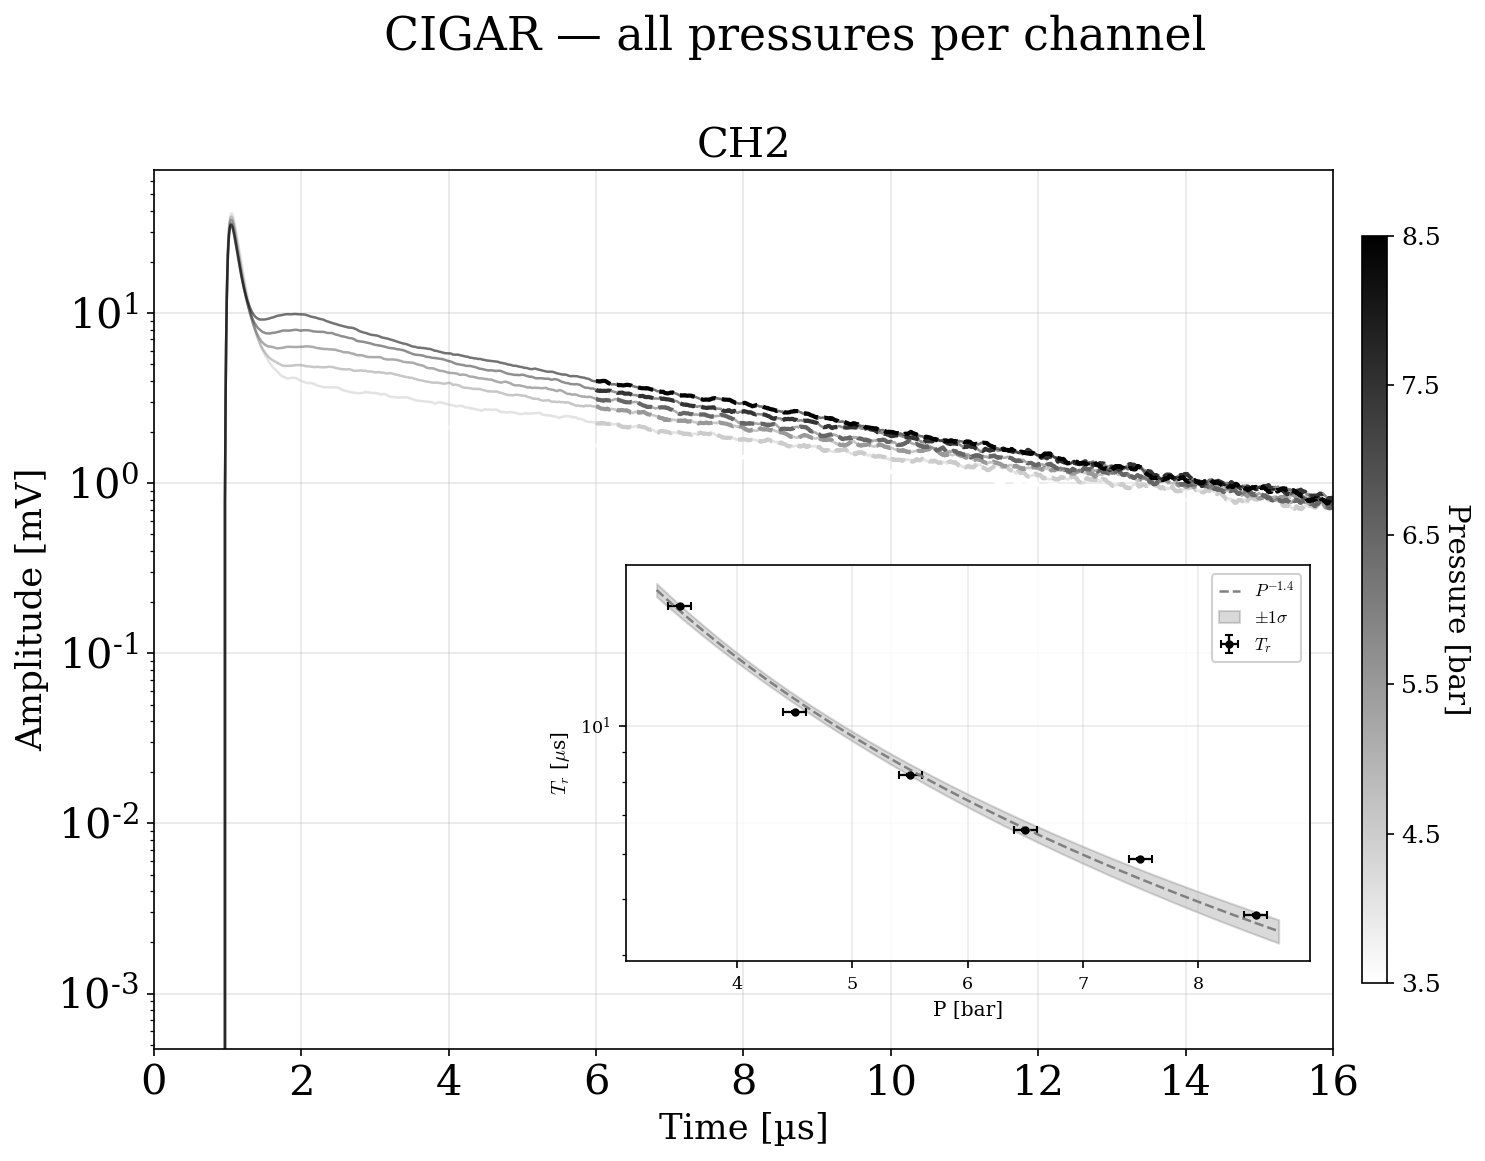

In [206]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as mcm
import matplotlib.colors as mcolors
import matplotlib.ticker

pressures_sorted = sorted(all_fits.keys())
cmap      = mcm.get_cmap("gray_r")
norm      = mcolors.Normalize(vmin=min(pressures_sorted), vmax=max(pressures_sorted))
press2col = lambda p: cmap(norm(p))

channels_ordered = sorted(
    {ch for bar_data in all_fits.values() for ch in bar_data},
    key=lambda x: int(x[2:])
)

# channels_to_show = channels_ordered[:4]
channels_to_show = [channels_ordered[1]]

if len(channels_to_show) > 1:
    fig_sum, axs_sum = plt.subplots(2, 2, figsize=(22, 16), dpi=150)
else:
    fig_sum, axs_sum = plt.subplots(1, 1, figsize=(11, 8), dpi=150)

fig_sum.suptitle("CIGAR — all pressures per channel", fontsize=font_size + 2)

def fit_fn(pressure_in_bar, A, power):
    return A * pressure_in_bar ** power

for panel_i, ch in enumerate(channels_to_show):

    if np.size(axs_sum) > 1:
        ax = axs_sum.flat[panel_i]
    else:
        ax = axs_sum


    for bars in pressures_sorted:
        if ch not in all_fits.get(bars, {}): continue
        d   = all_fits[bars][ch]
        col = press2col(bars)
        ax.semilogy(d["t"]*1e6, d["wf"],             lw=1.2, alpha=0.55, color=col)
        if d["fit_ok"]:
            ax.semilogy(d["t_fit"]*1e6, d["wf_fit"], lw=2.0, ls="--",   color=col)

    ax.set_xlabel("Time [µs]",       fontsize=font_size * 0.85)
    ax.set_ylabel("Amplitude [mV]",  fontsize=font_size * 0.85)
    ax.set_title(ch,                 fontsize=font_size)
    ax.set_xlim(0, 16)
    ax.grid(True, alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig_sum.colorbar(sm, ax=ax, pad=0.02, aspect=30, shrink=0.85)
    cbar.set_label("Pressure [bar]", fontsize=font_size*0.70, rotation=270, labelpad=14)
    cbar.set_ticks(pressures_sorted)
    cbar.ax.tick_params(labelsize=font_size*0.60)

    # ── inset ──
    if panel_i <2:
        ax_in = ax.inset_axes([0.40, 0.10, 0.58, 0.45])
    else:
        ax_in = ax.inset_axes([0.40, 0.50, 0.58, 0.45])

    bars_list = sorted(rec_Tr.get(ch, {}).keys())
    if bars_list:
        Tr_vals = np.array([rec_Tr[ch][b][0] for b in bars_list]) * 1e6
        err_Tr  = np.array([rec_Tr[ch][b][1] for b in bars_list]) * 1e6

        ax_in.errorbar(np.array(bars_list), Tr_vals, 
                       yerr=err_Tr,
                       xerr=0.1,
                       fmt="o", color="black", ms=3, lw=1.1, capsize=2,
                       label=r"$T_r$")

        # --- fit ---
        p0     = [6e4, -2.7]
        bounds = ([0, -10], [np.inf, 0])
        N_PARAMS = 2
        try:
            popt, pcov = curve_fit(fit_fn, np.array(bars_list), Tr_vals,
                                   bounds=bounds, p0=p0, maxfev=10_000)
            for _ in range(10):
                lo_r = np.minimum(popt * 0.6, popt * 1.4)
                hi_r = np.maximum(popt * 0.6, popt * 1.4)
                for i in range(N_PARAMS):
                    if not (lo_r[i] <= popt[i] <= hi_r[i]):
                        lo_r[i] = bounds[0][i]
                        hi_r[i] = bounds[1][i]
                popt, pcov = curve_fit(fit_fn, np.array(bars_list), Tr_vals,
                                       p0=popt, bounds=(lo_r, hi_r),
                                       maxfev=1_000, ftol=1e-12, xtol=1e-12)
            perr, fit_ok = np.sqrt(np.diag(pcov)), True
        except RuntimeError:
            fit_ok = False

        if fit_ok:
            p_fit        = np.linspace(min(bars_list) - 0.2, max(bars_list) + 0.2, 100)
            y_fit        = fit_fn(p_fit, *popt)
            A_fit, power_fit = popt

            dfdA     = p_fit ** power_fit
            dfdpower = A_fit * p_fit ** power_fit * np.log(p_fit)
            y_std    = np.sqrt(dfdA**2 * pcov[0,0]
                             + dfdpower**2 * pcov[1,1]
                             + 2 * dfdA * dfdpower * pcov[0,1])

            ax_in.plot(p_fit, y_fit, color="grey", lw=1.2, ls="--",
                       label=fr"$P^{{{power_fit:.1f}}}$")
            ax_in.fill_between(p_fit, y_fit - y_std, y_fit + y_std,
                               color="black", alpha=0.15, label=r"$\pm1\sigma$")

    ax_in.set_xlabel(r"P [bar]",          fontsize=font_size*0.48)
    ax_in.set_ylabel(r"$T_r$ [$\mu$s]",   fontsize=font_size*0.48, color="black")
    ax_in.tick_params(labelsize=font_size*0.42)
    ax_in.set_yscale("log")
    # fix oversized minor tick labels on log axis
    ax_in.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    ax_in.yaxis.set_major_formatter(matplotlib.ticker.LogFormatterSciNotation(labelOnlyBase=True))
    ax_in.patch.set_facecolor("white")
    ax_in.patch.set_alpha(0.85)
    ax_in.legend(fontsize=font_size*0.42, loc="upper right",
                 framealpha=0.90, handlelength=1.2)
    ax_in.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [207]:
len(channels_to_show)

1

In [208]:
np.size(channels_ordered[1])

1